# Restarted Cascade Deep BSDE


## 1. Setup


In [ ]:
from __future__ import annotations

import copy
import math
import random
from dataclasses import dataclass
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from torch import Tensor, nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123



In [ ]:
@dataclass(frozen=True)
class Config:
    T: float = 1.0
    sigma: float = 1.0
    alpha: float = 1.0

    # Domains
    x_min: float = 1.0
    x_max: float = 4.0
    singleton_x_min: float = 2.001
    max_restart_time: float = 0.95

    train_steps: int = 40
    restart_time_levels: int = 41

    width: int = 64
    depth: int = 3

    iterations_singleton: int = 15_000
    iterations_n2: int = 15_000
    batch_size: int = 1_024
    validation_size: int = 8_192

    learning_rate: float = 1.0e-3
    scheduler_step: int = 1_000
    scheduler_gamma: float = 0.95
    gradient_clip: float = 10.0
    validation_every: int = 200
    display_every: int = 1_000

    # Loss weights
    alive_state_weight: float = 0.10
    exit_step_weight: float = 0.10

    singleton_nonincreasing_weight: float = 0.25
    higher_range_weight: float = 0.05

    # Strict boundary sampling
    boundary_other_margin: float = 1.0e-4
    boundary_zero_tolerance: float = 5.0e-5
    boundary_sampling_rounds: int = 400
    boundary_proposal_multiplier: int = 4

    # Diagnostics
    validation_times: tuple[float, ...] = (0.00, 0.50, 0.90, 0.95)
    plot_grid: int = 181
    reference_grid: int = 51
    reference_paths: int = 2_048
    reference_coarse_steps: int = 40
    reference_fine_steps: int = 400
    reference_point_batch: int = 32
    diagnostic_size: int = 4_096
    projection_samples: int = 4_096

CFG = Config()


### Utility functions and monitoring masks


In [ ]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


def make_generator(seed: int) -> torch.Generator:
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)
    return generator


def uniform(
    shape: tuple[int, ...],
    low: float,
    high: float,
    generator: torch.Generator,
) -> Tensor:
    return low + (high - low) * torch.rand(
        shape,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )


def normal_cdf(value: Tensor) -> Tensor:
    return 0.5 * (1.0 + torch.erf(value / math.sqrt(2.0)))


def normal_pdf(value: Tensor) -> Tensor:
    return torch.exp(-0.5 * value.square()) / math.sqrt(2.0 * math.pi)


def masked_mean(value: Tensor, mask: Tensor) -> Tensor:
    if bool(mask.any()):
        return value[mask].mean()
    return value.sum() * 0.0


def first_true_index(mask: Tensor) -> tuple[Tensor, Tensor]:
    """First monitored hit index and hit flag."""
    hit = mask.any(dim=1)
    index = mask.to(torch.int64).argmax(dim=1)
    final_index = mask.shape[1] - 1
    index = torch.where(
        hit,
        index,
        torch.full_like(index, final_index),
    )
    return index, hit


def living_interval_mask(
    stop_index: Tensor,
    hit: Tensor,
    number_of_intervals: int,
) -> Tensor:
    """Intervals before the first monitored exit."""
    interval_end_index = torch.arange(
        1,
        number_of_intervals + 1,
        device=stop_index.device,
    )[None, :]
    return (
        (~hit)[:, None]
        | (stop_index[:, None] > interval_end_index)
    )


def first_exit_interval_mask(
    stop_index: Tensor,
    hit: Tensor,
    number_of_intervals: int,
) -> Tensor:
    """Interval ending at the first monitored exit."""
    interval_end_index = torch.arange(
        1,
        number_of_intervals + 1,
        device=stop_index.device,
    )[None, :]
    return (
        hit[:, None]
        & (stop_index[:, None] == interval_end_index)
    )


def time_column(
    t: float | Tensor,
    batch_size: int,
    *,
    device: torch.device,
    dtype: torch.dtype,
) -> Tensor:
    value = torch.as_tensor(t, device=device, dtype=dtype)
    if value.ndim == 0:
        value = value.expand(batch_size)
    return value.reshape(batch_size, 1)


def tensor_to_numpy(value: Tensor) -> np.ndarray:
    return value.detach().cpu().numpy()



DISPLAY_LABELS = {
    "time": "Time",
    "N": "N",
    "level": "Level",
    "best_iteration": "Best iteration",
    "best_validation_loss": "Best validation",
    "stopped": "Stopped",
    "living": "Living",
    "exit": "Exit",
    "boundary": "Boundary",
    "terminal": "Terminal",
    "noninc": "Non-increasing",
    "range": "Range",
    "hit_rate": "Hit rate",
    "no_hit_rate": "No-hit rate",
    "mean_stop_fraction": "Mean stop fraction",
    "mean_living_intervals": "Mean living intervals",
    "immediate_exit_rate": "Immediate-exit rate",
    "positive_time_hit_rate": "Positive-time hit rate",
    "domain_sample_fraction": "Domain fraction",
    "field_min_on_domain": "Field minimum",
    "field_max_on_domain": "Field maximum",
    "range_violation_rate": "Range violation",
    "value_symmetry_max_error": "Value symmetry error",
    "z_equivariance_max_error": "Z equivariance error",
    "boundary_MAE": "Boundary MAE",
    "boundary_RMSE": "Boundary RMSE",
    "terminal_MAE": "Terminal MAE",
    "terminal_RMSE": "Terminal RMSE",
    "singleton_MAE": "Singleton MAE",
    "singleton_RMSE": "Singleton RMSE",
    "singleton_max_error": "Singleton maximum error",
    "boundary_max_error": "Boundary maximum error",
    "MAE": "MAE",
    "RMSE": "RMSE",
    "max_error": "Maximum error",
    "field_MAE": "Field MAE",
    "field_RMSE": "Field RMSE",
    "field_max_error": "Field maximum error",
    "reference_mean_MC_SE": "Mean Monte Carlo SE",
    "reference_max_MC_SE": "Maximum Monte Carlo SE",
    "singleton_Z_MAE": "Singleton Z MAE",
    "singleton_Z_RMSE": "Singleton Z RMSE",
    "z_gradient_MAE": "Z-gradient MAE",
    "z_gradient_RMSE": "Z-gradient RMSE",
    "far_coordinate": "Far coordinate L",
    "max_boundary_hit_bound": "Exact-system direct-hit bound",
}


def show_table(
    table: pd.DataFrame,
    title: str,
    *,
    decimals: int = 6,
) -> None:
    """Display a consistently labelled thesis-style results table."""
    display(Markdown(f"#### {title}"))
    renamed = table.rename(columns=DISPLAY_LABELS)
    numeric = renamed.select_dtypes(include=[np.number]).columns
    formatter = {column: f"{{:.{decimals}f}}" for column in numeric}
    display(
        renamed.style
        .format(formatter, na_rep="—")
        .hide(axis="index")
    )


# Check no-hit paths keep all intervals.
_test_stop = torch.tensor([CFG.train_steps, 3], device=DEVICE)
_test_hit = torch.tensor([False, True], device=DEVICE)
_test_living = living_interval_mask(
    _test_stop,
    _test_hit,
    CFG.train_steps,
)
assert int(_test_living[0].sum()) == CFG.train_steps
assert int(_test_living[1].sum()) == 2


### Neural architectures


In [ ]:
class NormalisedMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        width: int,
        depth: int,
        center: tuple[float, ...],
        scale: tuple[float, ...],
    ) -> None:
        super().__init__()

        self.register_buffer(
            "center",
            torch.tensor(center, dtype=DTYPE).reshape(1, -1),
        )
        self.register_buffer(
            "scale",
            torch.tensor(scale, dtype=DTYPE).reshape(1, -1),
        )

        layers: list[nn.Module] = []
        current = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(current, width))
            layers.append(nn.Softplus())
            current = width
        layers.append(nn.Linear(current, output_dim))

        self.network = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: Tensor) -> Tensor:
        return self.network((x - self.center) / self.scale)


class SingletonFBSDE(nn.Module):
    def __init__(self, cfg: Config) -> None:
        super().__init__()

        x_min = 2.0 * cfg.alpha
        x_max = cfg.x_max
        x_center = 0.5 * (x_min + x_max)
        x_scale = 0.5 * (x_max - x_min)

        self.value_net = NormalisedMLP(
            2,
            1,
            cfg.width,
            cfg.depth,
            center=(0.5, x_center),
            scale=(0.5, x_scale),
        )
        self.z_net = NormalisedMLP(
            2,
            1,
            cfg.width,
            cfg.depth,
            center=(0.5, x_center),
            scale=(0.5, x_scale),
        )

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        x = x.reshape(-1)
        tc = time_column(
            t, x.shape[0], device=x.device, dtype=x.dtype
        )
        raw = self.value_net(
            torch.cat((tc, x[:, None]), dim=1)
        )[:, 0]

        # Aggregate singleton value lies between one and two.
        return 1.0 + torch.sigmoid(raw)

    def z(self, t: float | Tensor, x: Tensor) -> Tensor:
        x = x.reshape(-1)
        tc = time_column(
            t, x.shape[0], device=x.device, dtype=x.dtype
        )
        return self.z_net(
            torch.cat((tc, x[:, None]), dim=1)
        )[:, 0]


class SymmetricTwoParticleFBSDE(nn.Module):
    def __init__(self, cfg: Config) -> None:
        super().__init__()

        x_center = 0.5 * (cfg.x_min + cfg.x_max)
        x_scale = 0.5 * (cfg.x_max - cfg.x_min)

        self.value_net = NormalisedMLP(
            3,
            1,
            cfg.width,
            cfg.depth,
            center=(0.5, x_center, 0.5 * x_scale**2),
            scale=(0.5, x_scale, 0.5 * x_scale**2),
        )
        self.z_component_net = NormalisedMLP(
            3,
            1,
            cfg.width,
            cfg.depth,
            center=(0.5, x_center, x_center),
            scale=(0.5, x_scale, x_scale),
        )

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        tc = time_column(
            t, x.shape[0], device=x.device, dtype=x.dtype
        )
        mean = x.mean(dim=1, keepdim=True)
        half_gap_squared = 0.25 * (
            x[:, 0:1] - x[:, 1:2]
        ).square()

        return self.value_net(
            torch.cat((tc, mean, half_gap_squared), dim=1)
        )[:, 0]

    def z(self, t: float | Tensor, x: Tensor) -> Tensor:
        tc = time_column(
            t, x.shape[0], device=x.device, dtype=x.dtype
        )

        z1 = self.z_component_net(
            torch.cat((tc, x[:, 0:1], x[:, 1:2]), dim=1)
        )
        z2 = self.z_component_net(
            torch.cat((tc, x[:, 1:2], x[:, 0:1]), dim=1)
        )
        return torch.cat((z1, z2), dim=1)

### Restarted Brownian batches


In [ ]:
@dataclass
class BrownianBatch:
    start_time: Tensor
    times: Tensor
    x0: Tensor
    paths: Tensor
    dW: Tensor


def stratified_restart_times(
    size: int,
    cfg: Config,
    generator: torch.Generator,
) -> Tensor:
    grid = torch.linspace(
        0.0,
        cfg.max_restart_time,
        cfg.restart_time_levels,
        device=DEVICE,
        dtype=DTYPE,
    )

    repeats = math.ceil(size / len(grid))
    values = grid.repeat(repeats)[:size]

    permutation = torch.randperm(
        size,
        generator=generator,
        device=DEVICE,
    )
    return values[permutation]


def sample_brownian_batch(
    *,
    batch_size: int,
    dimension: int,
    x_min: float,
    x_max: float,
    cfg: Config,
    generator: torch.Generator,
    antithetic: bool,
) -> BrownianBatch:
    if antithetic and batch_size % 2 != 0:
        raise ValueError("antithetic batch size must be even")

    base_size = batch_size // 2 if antithetic else batch_size

    start_time = stratified_restart_times(
        base_size, cfg, generator
    )

    x0 = uniform(
        (base_size, dimension),
        x_min,
        x_max,
        generator,
    )

    normals = torch.randn(
        base_size,
        cfg.train_steps,
        dimension,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )

    if antithetic:
        start_time = torch.cat(
            (start_time, start_time.clone()), dim=0
        )
        x0 = torch.cat((x0, x0.clone()), dim=0)
        normals = torch.cat((normals, -normals), dim=0)

    dt = (cfg.T - start_time) / cfg.train_steps
    dW = torch.sqrt(dt)[:, None, None] * normals
    dX = cfg.sigma * dW

    zero = torch.zeros(
        batch_size,
        1,
        dimension,
        device=DEVICE,
        dtype=DTYPE,
    )

    paths = x0[:, None, :] + torch.cat(
        (zero, dX.cumsum(dim=1)),
        dim=1,
    )

    fraction = torch.arange(
        cfg.train_steps + 1,
        device=DEVICE,
        dtype=DTYPE,
    )[None, :] / cfg.train_steps

    times = (
        start_time[:, None]
        + (cfg.T - start_time)[:, None] * fraction
    )

    return BrownianBatch(
        start_time=start_time,
        times=times,
        x0=x0,
        paths=paths,
        dW=dW,
    )


def forward_singleton(
    model: SingletonFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
) -> Tensor:
    y = model.value(
        batch.start_time,
        batch.x0[:, 0],
    )

    for k in range(batch.dW.shape[1]):
        in_current_level = (stop_index > k).to(DTYPE)
        z = model.z(
            batch.times[:, k],
            batch.paths[:, k, 0],
        )
        y = (
            y
            + in_current_level
            * z
            * batch.dW[:, k, 0]
        )

    return y


def forward_two_particle(
    model: SymmetricTwoParticleFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
) -> Tensor:
    y = model.value(
        batch.start_time,
        batch.x0,
    )

    for k in range(batch.dW.shape[1]):
        in_current_level = (stop_index > k).to(DTYPE)
        z = model.z(
            batch.times[:, k],
            batch.paths[:, k],
        )

        y = (
            y
            + in_current_level
            * (z * batch.dW[:, k]).sum(dim=1)
        )

    return y

### Local martingale losses


In [ ]:
def local_configuration_losses(
    *,
    value_function,
    z_function,
    batch: BrownianBatch,
    stop_index: Tensor,
    stop_target: Tensor,
    hit: Tensor,
) -> tuple[Tensor, Tensor]:
    """One-step martingale losses before and across the first monitored exit."""
    alive_total = batch.dW.new_tensor(0.0)
    alive_count = batch.dW.new_tensor(0.0)

    exit_total = batch.dW.new_tensor(0.0)
    exit_count = batch.dW.new_tensor(0.0)

    number_of_intervals = batch.dW.shape[1]
    living_mask = living_interval_mask(
        stop_index,
        hit,
        number_of_intervals,
    )
    exit_mask = first_exit_interval_mask(
        stop_index,
        hit,
        number_of_intervals,
    )

    for k in range(number_of_intervals):
        current_value = value_function(
            batch.times[:, k],
            batch.paths[:, k],
        )
        z = z_function(
            batch.times[:, k],
            batch.paths[:, k],
        )

        if z.ndim == 1:
            increment = z * batch.dW[:, k, 0]
        else:
            increment = (z * batch.dW[:, k]).sum(dim=1)

        one_step = current_value + increment

        next_value = value_function(
            batch.times[:, k + 1],
            batch.paths[:, k + 1],
        )

        remains_alive = living_mask[:, k]
        if bool(remains_alive.any()):
            error = (one_step - next_value).square()
            alive_total = alive_total + error[remains_alive].sum()
            alive_count = alive_count + remains_alive.to(DTYPE).sum()

        first_exit_next = exit_mask[:, k]
        if bool(first_exit_next.any()):
            error = (one_step - stop_target).square()
            exit_total = exit_total + error[first_exit_next].sum()
            exit_count = exit_count + first_exit_next.to(DTYPE).sum()

    return (
        alive_total / alive_count.clamp_min(1.0),
        exit_total / exit_count.clamp_min(1.0),
    )


def singleton_configuration_losses(
    model: SingletonFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
    stop_target: Tensor,
    hit: Tensor,
) -> tuple[Tensor, Tensor]:
    return local_configuration_losses(
        value_function=lambda t, x: model.value(t, x[:, 0]),
        z_function=lambda t, x: model.z(t, x[:, 0]),
        batch=batch,
        stop_index=stop_index,
        stop_target=stop_target,
        hit=hit,
    )


def n2_configuration_losses(
    model: SymmetricTwoParticleFBSDE,
    batch: BrownianBatch,
    stop_index: Tensor,
    stop_target: Tensor,
    hit: Tensor,
) -> tuple[Tensor, Tensor]:
    return local_configuration_losses(
        value_function=model.value,
        z_function=model.z,
        batch=batch,
        stop_index=stop_index,
        stop_target=stop_target,
        hit=hit,
    )


### Training and checkpoint selection


In [ ]:
@dataclass
class TrainingResult:
    best_iteration: int
    best_validation_loss: float
    history: pd.DataFrame


def train(
    *,
    model: nn.Module,
    name: str,
    train_objective: Callable[[nn.Module], tuple[Tensor, dict[str, Tensor]]],
    validation_objective: Callable[[nn.Module], tuple[Tensor, dict[str, Tensor]]],
    iterations: int,
    cfg: Config,
) -> TrainingResult:
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=cfg.scheduler_step,
        gamma=cfg.scheduler_gamma,
    )

    best_loss = math.inf
    best_iteration = 0
    best_state = copy.deepcopy(model.state_dict())
    records = []

    for iteration in range(1, iterations + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        loss, pieces = train_objective(model)

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f"Non-finite loss in {name}"
            )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            cfg.gradient_clip,
        )
        optimizer.step()
        scheduler.step()

        if (
            iteration % cfg.validation_every == 0
            or iteration == iterations
        ):
            model.eval()

            with torch.enable_grad():
                validation_loss, validation_pieces = (
                    validation_objective(model)
                )

            value = float(validation_loss.detach().cpu())

            if value < best_loss:
                best_loss = value
                best_iteration = iteration
                best_state = copy.deepcopy(
                    model.state_dict()
                )

            record = {
                "iteration": iteration,
                "training_loss": float(loss.detach().cpu()),
                "validation_loss": value,
            }
            for key, item in validation_pieces.items():
                record[key] = float(
                    item.detach().cpu()
                )
            records.append(record)

            if (
                iteration % cfg.display_every == 0
                or iteration == iterations
            ):
                extra = " ".join(
                    f"{key}={record[key]:.3e}"
                    for key in validation_pieces
                )
                print(
                    f"{name:24s} "
                    f"iter={iteration:5d} "
                    f"val={value:.4e} "
                    f"{extra}"
                )

    model.load_state_dict(best_state)
    model.eval()

    history = pd.DataFrame(records)

    print(f"{name} complete best_iter={best_iteration} best_val={best_loss:.4e}")

    return TrainingResult(
        best_iteration=best_iteration,
        best_validation_loss=best_loss,
        history=history,
    )

## 2. Two-particle cascade


### Singleton objective


In [ ]:
def sample_singleton_training_data(
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
    cfg: Config,
):
    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=1,
        x_min=cfg.singleton_x_min,
        x_max=cfg.x_max,
        cfg=cfg,
        generator=generator,
        antithetic=antithetic,
    )

    boundary_time = stratified_restart_times(
        batch_size, cfg, generator
    )

    terminal_x = uniform(
        (batch_size,),
        2.0 * cfg.alpha + 0.001,
        cfg.x_max,
        generator,
    )

    nonincreasing_time = stratified_restart_times(
        batch_size, cfg, generator
    )
    nonincreasing_x = uniform(
        (batch_size,),
        2.0 * cfg.alpha + 0.001,
        cfg.x_max,
        generator,
    )

    return (
        batch,
        boundary_time,
        terminal_x,
        nonincreasing_time,
        nonincreasing_x,
    )


def singleton_loss(
    *,
    model: SingletonFBSDE,
    data,
    cfg: Config,
) -> tuple[Tensor, dict[str, Tensor]]:
    (
        batch,
        boundary_time,
        terminal_x,
        nonincreasing_time,
        nonincreasing_x,
    ) = data

    threshold = 2.0 * cfg.alpha

    outside_domain = (
        batch.paths[:, :, 0] <= threshold
    )
    stop_index, hit = first_true_index(
        outside_domain
    )

    stop_target = torch.where(
        hit,
        torch.full_like(batch.start_time, 2.0),
        torch.full_like(batch.start_time, 1.0),
    )

    stopped_y = forward_singleton(
        model,
        batch,
        stop_index,
    )
    stopped_loss = (
        stopped_y - stop_target
    ).square().mean()

    alive_state_loss, exit_step_loss = (
        singleton_configuration_losses(
            model,
            batch,
            stop_index,
            stop_target,
            hit,
        )
    )

    boundary_prediction = model.value(
        boundary_time,
        torch.full_like(
            boundary_time,
            threshold,
        ),
    )
    boundary_condition_loss = (
        boundary_prediction - 2.0
    ).square().mean()

    terminal_prediction = model.value(
        cfg.T,
        terminal_x,
    )
    terminal_loss = (
        terminal_prediction - 1.0
    ).square().mean()

    x_for_derivative = (
        nonincreasing_x.detach()
        .clone()
        .requires_grad_(True)
    )
    value_for_derivative = model.value(
        nonincreasing_time,
        x_for_derivative,
    )
    spatial_derivative = torch.autograd.grad(
        value_for_derivative.sum(),
        x_for_derivative,
        create_graph=True,
    )[0]

    nonincreasing_loss = torch.relu(
        spatial_derivative
    ).square().mean()

    total = (
        stopped_loss
        + cfg.alive_state_weight * alive_state_loss
        + cfg.exit_step_weight * exit_step_loss
        + boundary_condition_loss
        + terminal_loss
        + cfg.singleton_nonincreasing_weight
        * nonincreasing_loss
    )

    return total, {
        "stopped": stopped_loss,
        "alive": alive_state_loss,
        "exit": exit_step_loss,
        "boundary": boundary_condition_loss,
        "terminal": terminal_loss,
        "noninc": nonincreasing_loss,
    }

### Train and freeze the singleton


In [ ]:
seed_everything(SEED + 500)

singleton_model = SingletonFBSDE(
    CFG
).to(DEVICE)

singleton_train_generator = make_generator(
    SEED + 501
)
singleton_validation_generator = make_generator(
    SEED + 502
)

singleton_validation_data = (
    sample_singleton_training_data(
        batch_size=CFG.validation_size,
        generator=singleton_validation_generator,
        antithetic=False,
        cfg=CFG,
    )
)


def singleton_train_objective(model):
    data = sample_singleton_training_data(
        batch_size=CFG.batch_size,
        generator=singleton_train_generator,
        antithetic=True,
        cfg=CFG,
    )
    return singleton_loss(
        model=model,
        data=data,
        cfg=CFG,
    )


def singleton_validation_objective(model):
    return singleton_loss(
        model=model,
        data=singleton_validation_data,
        cfg=CFG,
    )


singleton_training = train(
    model=singleton_model,
    name="singleton",
    train_objective=singleton_train_objective,
    validation_objective=singleton_validation_objective,
    iterations=CFG.iterations_singleton,
    cfg=CFG,
)

for parameter in singleton_model.parameters():
    parameter.requires_grad_(False)


@torch.no_grad()
def learned_singleton_value(
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    tt = torch.as_tensor(
        t, device=x.device, dtype=x.dtype
    )
    tt, xx = torch.broadcast_tensors(tt, x)

    raw = singleton_model.value(
        tt.reshape(-1),
        xx.reshape(-1),
    ).reshape(xx.shape)

    return torch.where(
        xx <= 2.0 * CFG.alpha,
        torch.full_like(raw, 2.0),
        raw,
    )


def learned_boundary_value(
    t: float | Tensor,
    survivor: Tensor,
) -> Tensor:
    return (
        CFG.alpha
        * learned_singleton_value(
            t, survivor
        )
    )

singleton                iter= 1000 val=5.8927e-02 stopped=3.506e-02 alive=2.399e-03 exit=4.593e-02 boundary=1.021e-02 terminal=8.825e-03 noninc=0.000e+00
singleton                iter= 2000 val=3.3135e-02 stopped=1.934e-02 alive=1.579e-03 exit=3.539e-02 boundary=5.565e-03 terminal=4.535e-03 noninc=0.000e+00
singleton                iter= 3000 val=1.9775e-02 stopped=1.368e-02 alive=9.302e-04 exit=2.816e-02 boundary=2.418e-03 terminal=7.708e-04 noninc=0.000e+00
singleton                iter= 4000 val=1.5928e-02 stopped=1.146e-02 alive=6.317e-04 exit=2.361e-02 boundary=1.666e-03 terminal=3.736e-04 noninc=0.000e+00
singleton                iter= 5000 val=1.3359e-02 stopped=9.863e-03 alive=4.139e-04 exit=2.194e-02 boundary=9.732e-04 terminal=2.878e-04 noninc=0.000e+00
singleton                iter= 6000 val=1.2147e-02 stopped=9.348e-03 alive=3.386e-04 exit=2.035e-02 boundary=6.152e-04 terminal=1.151e-04 noninc=0.000e+00
singleton                iter= 7000 val=1.1168e-02 stopped=8.560e-03 a

### Singleton validation


#### N=2 singleton and moving-boundary diagnostics

Time,Singleton MAE,Singleton RMSE,Singleton maximum error,Boundary MAE,Boundary RMSE,Boundary maximum error,Singleton Z MAE,Singleton Z RMSE
0.000000,0.043391,0.047228,0.079097,0.043391,0.047228,0.079097,0.027420,0.037062
0.500000,0.030304,0.038501,0.078379,0.030304,0.038501,0.078379,0.051872,0.067237
0.900000,0.010804,0.021865,0.081127,0.010804,0.021865,0.081127,0.104511,0.171165
0.950000,0.008262,0.017387,0.051959,0.008262,0.017387,0.051959,0.145151,0.292420


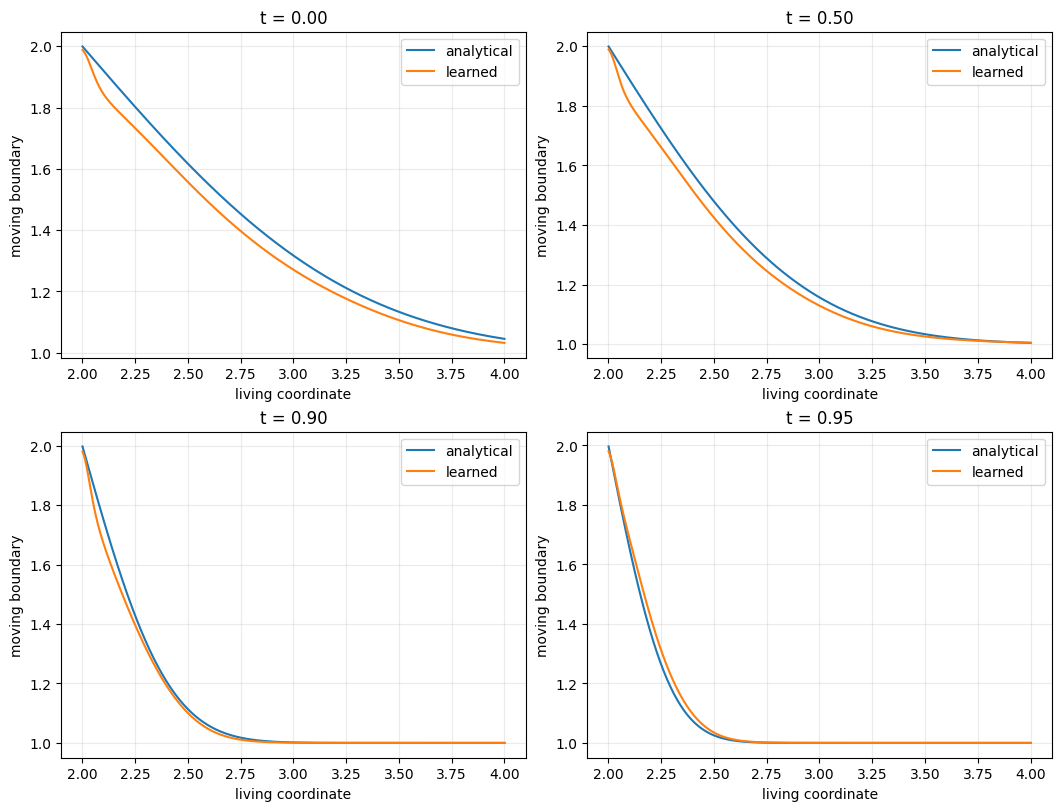

In [ ]:
@torch.no_grad()
def exact_singleton_value(
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    tt = torch.as_tensor(
        t, device=x.device, dtype=x.dtype
    )
    tt, xx = torch.broadcast_tensors(
        tt, x
    )

    remaining = CFG.T - tt

    terminal = torch.where(
        xx <= 2.0 * CFG.alpha,
        torch.full_like(xx, 2.0),
        torch.full_like(xx, 1.0),
    )

    safe_remaining = remaining.clamp_min(
        torch.finfo(xx.dtype).eps
    )

    argument = torch.minimum(
        (
            2.0 * CFG.alpha - xx
        )
        / (
            CFG.sigma
            * torch.sqrt(safe_remaining)
        ),
        torch.zeros_like(xx),
    )

    preterminal = (
        1.0
        + 2.0 * normal_cdf(argument)
    )

    return torch.where(
        remaining <= 1.0e-12,
        terminal,
        preterminal,
    )



@torch.no_grad()
def exact_singleton_z(
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    tt = torch.as_tensor(
        t, device=x.device, dtype=x.dtype
    )
    tt, xx = torch.broadcast_tensors(
        tt, x
    )

    remaining = CFG.T - tt
    safe_remaining = remaining.clamp_min(
        torch.finfo(xx.dtype).eps
    )

    threshold = 2.0 * CFG.alpha
    argument = (
        threshold - xx
    ) / (
        CFG.sigma
        * torch.sqrt(safe_remaining)
    )

    preterminal = (
        -2.0
        * normal_pdf(argument)
        / torch.sqrt(safe_remaining)
    )

    return torch.where(
        (xx <= threshold)
        | (remaining <= 1.0e-12),
        torch.zeros_like(xx),
        preterminal,
    )


@torch.no_grad()
def singleton_validation_table() -> pd.DataFrame:
    x = torch.linspace(
        2.001,
        CFG.x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )

    rows = []
    for t in CFG.validation_times:
        learned = learned_singleton_value(
            t, x
        )
        exact = exact_singleton_value(
            t, x
        )
        error = learned - exact

        learned_z = singleton_model.z(
            t,
            x,
        )
        exact_z = exact_singleton_z(
            t,
            x,
        )
        z_error = learned_z - exact_z

        rows.append({
            "time": t,
            "singleton_MAE": float(
                error.abs().mean().cpu()
            ),
            "singleton_RMSE": float(
                torch.sqrt(
                    error.square().mean()
                ).cpu()
            ),
            "singleton_max_error": float(
                error.abs().max().cpu()
            ),
            "boundary_MAE": float(
                (CFG.alpha * error).abs().mean().cpu()
            ),
            "boundary_RMSE": float(
                torch.sqrt(
                    (CFG.alpha * error).square().mean()
                ).cpu()
            ),
            "boundary_max_error": float(
                (CFG.alpha * error).abs().max().cpu()
            ),
            "singleton_Z_MAE": float(
                z_error.abs().mean().cpu()
            ),
            "singleton_Z_RMSE": float(
                torch.sqrt(
                    z_error.square().mean()
                ).cpu()
            ),
        })

    return pd.DataFrame(rows)


singleton_metrics = singleton_validation_table()
show_table(singleton_metrics, "N=2 singleton and moving-boundary diagnostics")


x = torch.linspace(
    2.001,
    CFG.x_max,
    500,
    device=DEVICE,
    dtype=DTYPE,
)

fig, axes = plt.subplots(
    2, 2,
    figsize=(10.5, 8.0),
    constrained_layout=True,
)

for ax, t in zip(
    axes.flat,
    CFG.validation_times,
):
    exact = (
        CFG.alpha
        * exact_singleton_value(t, x)
    )
    learned = learned_boundary_value(
        t, x
    )

    ax.plot(
        tensor_to_numpy(x),
        tensor_to_numpy(exact),
        label="analytical",
    )
    ax.plot(
        tensor_to_numpy(x),
        tensor_to_numpy(learned),
        label="learned",
    )

    ax.set_xlabel("living coordinate")
    ax.set_ylabel("moving boundary")
    ax.set_title(f"t = {t:.2f}")
    ax.grid(alpha=0.25)
    ax.legend()

plt.show()

### Train the two-particle field


In [ ]:
def n2_stop_target(
    batch: BrownianBatch,
) -> tuple[Tensor, Tensor, Tensor]:
    smaller = batch.paths.min(dim=2).values
    larger = batch.paths.max(dim=2).values

    threshold = learned_boundary_value(
        batch.times,
        larger,
    )

    lower_value = learned_singleton_value(
        batch.times,
        larger,
    )

    outside_domain = (
        smaller <= threshold
    )

    stop_index, hit = first_true_index(
        outside_domain
    )

    stopped_lower = lower_value.gather(
        1,
        stop_index[:, None],
    )[:, 0]

    stop_target = torch.where(
        hit,
        stopped_lower,
        torch.zeros_like(stopped_lower),
    )

    return (
        stop_index,
        stop_target,
        hit,
    )


def learned_n2_domain(
    t: float | Tensor,
    points: Tensor,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    threshold = learned_boundary_value(
        t,
        larger,
    )

    return smaller > threshold


def learned_terminal_domain(
    points: Tensor,
) -> Tensor:
    return learned_n2_domain(
        torch.ones(
            points.shape[0],
            device=points.device,
            dtype=points.dtype,
        ),
        points,
    )


def sample_n2_training_data(
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
):
    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=2,
        x_min=CFG.x_min,
        x_max=CFG.x_max,
        cfg=CFG,
        generator=generator,
        antithetic=antithetic,
    )

    boundary_time = stratified_restart_times(
        batch_size,
        CFG,
        generator,
    )

    survivor = uniform(
        (batch_size,),
        2.001,
        CFG.x_max,
        generator,
    )

    terminal_points = uniform(
        (batch_size, 2),
        CFG.x_min,
        CFG.x_max,
        generator,
    )

    range_time = stratified_restart_times(
        batch_size,
        CFG,
        generator,
    )

    range_points = uniform(
        (batch_size, 2),
        CFG.x_min,
        CFG.x_max,
        generator,
    )

    return (
        batch,
        boundary_time,
        survivor,
        terminal_points,
        range_time,
        range_points,
    )


def n2_loss(
    *,
    model: SymmetricTwoParticleFBSDE,
    data,
) -> tuple[Tensor, dict[str, Tensor]]:
    (
        batch,
        boundary_time,
        survivor,
        terminal_points,
        range_time,
        range_points,
    ) = data

    with torch.no_grad():
        stop_index, stop_target, hit = (
            n2_stop_target(batch)
        )

    stopped_y = forward_two_particle(
        model,
        batch,
        stop_index,
    )

    stopped_loss = (
        stopped_y
        - stop_target
    ).square().mean()

    alive_state_loss, exit_step_loss = (
        n2_configuration_losses(
            model,
            batch,
            stop_index,
            stop_target,
            hit,
        )
    )

    with torch.no_grad():
        threshold = learned_boundary_value(
            boundary_time,
            survivor,
        )

        lower_value = learned_singleton_value(
            boundary_time,
            survivor,
        )

    boundary_point_one = torch.stack(
        (
            threshold,
            survivor,
        ),
        dim=1,
    )

    boundary_point_two = torch.stack(
        (
            survivor,
            threshold,
        ),
        dim=1,
    )

    boundary_condition_loss = 0.5 * (
        (
            model.value(
                boundary_time,
                boundary_point_one,
            )
            - lower_value
        ).square().mean()
        +
        (
            model.value(
                boundary_time,
                boundary_point_two,
            )
            - lower_value
        ).square().mean()
    )

    with torch.no_grad():
        terminal_in_domain = (
            learned_terminal_domain(
                terminal_points
            )
        )

    terminal_prediction = model.value(
        CFG.T,
        terminal_points,
    )

    terminal_loss = masked_mean(
        terminal_prediction.square(),
        terminal_in_domain,
    )

    with torch.no_grad():
        range_in_domain = learned_n2_domain(
            range_time,
            range_points,
        )

    range_prediction = model.value(
        range_time,
        range_points,
    )

    range_penalty = (
        torch.relu(
            -range_prediction
        ).square()
        +
        torch.relu(
            range_prediction - 2.0
        ).square()
    )
    range_loss = masked_mean(
        range_penalty,
        range_in_domain,
    )

    total = (
        stopped_loss
        + CFG.alive_state_weight
        * alive_state_loss
        + CFG.exit_step_weight
        * exit_step_loss
        + boundary_condition_loss
        + terminal_loss
        + CFG.higher_range_weight
        * range_loss
    )

    return total, {
        "stopped": stopped_loss,
        "alive": alive_state_loss,
        "exit": exit_step_loss,
        "boundary": boundary_condition_loss,
        "terminal": terminal_loss,
        "range": range_loss,
    }


seed_everything(SEED + 600)


n2_model = SymmetricTwoParticleFBSDE(
    CFG
).to(DEVICE)


n2_train_generator = make_generator(
    SEED + 601
)

n2_validation_generator = make_generator(
    SEED + 602
)


n2_validation_data = sample_n2_training_data(
    batch_size=CFG.validation_size,
    generator=n2_validation_generator,
    antithetic=False,
)


def n2_train_objective(model):
    data = sample_n2_training_data(
        batch_size=CFG.batch_size,
        generator=n2_train_generator,
        antithetic=True,
    )

    return n2_loss(
        model=model,
        data=data,
    )


def n2_validation_objective(model):
    return n2_loss(
        model=model,
        data=n2_validation_data,
    )


n2_training = train(
    model=n2_model,
    name="n2",
    train_objective=n2_train_objective,
    validation_objective=n2_validation_objective,
    iterations=CFG.iterations_n2,
    cfg=CFG,
)

n2                       iter= 1000 val=2.7853e-01 stopped=1.287e-01 alive=1.746e-03 exit=1.782e-01 boundary=9.096e-02 terminal=4.068e-02 range=3.105e-03
n2                       iter= 2000 val=2.4392e-01 stopped=1.094e-01 alive=1.904e-03 exit=1.597e-01 boundary=7.666e-02 terminal=4.161e-02 range=2.261e-03
n2                       iter= 3000 val=1.5669e-01 stopped=7.070e-02 alive=1.304e-03 exit=1.258e-01 boundary=4.510e-02 terminal=2.816e-02 range=5.112e-04
n2                       iter= 4000 val=9.0811e-02 stopped=4.260e-02 alive=1.140e-03 exit=7.634e-02 boundary=2.742e-02 terminal=1.303e-02 range=2.242e-04
n2                       iter= 5000 val=6.9766e-02 stopped=3.505e-02 alive=1.322e-03 exit=5.638e-02 boundary=1.913e-02 terminal=9.802e-03 range=2.985e-04
n2                       iter= 6000 val=5.9592e-02 stopped=3.229e-02 alive=1.375e-03 exit=4.755e-02 boundary=1.213e-02 terminal=1.029e-02 range=4.774e-07
n2                       iter= 7000 val=4.8737e-02 stopped=2.639e-02 alive=1

### Learned two-particle field


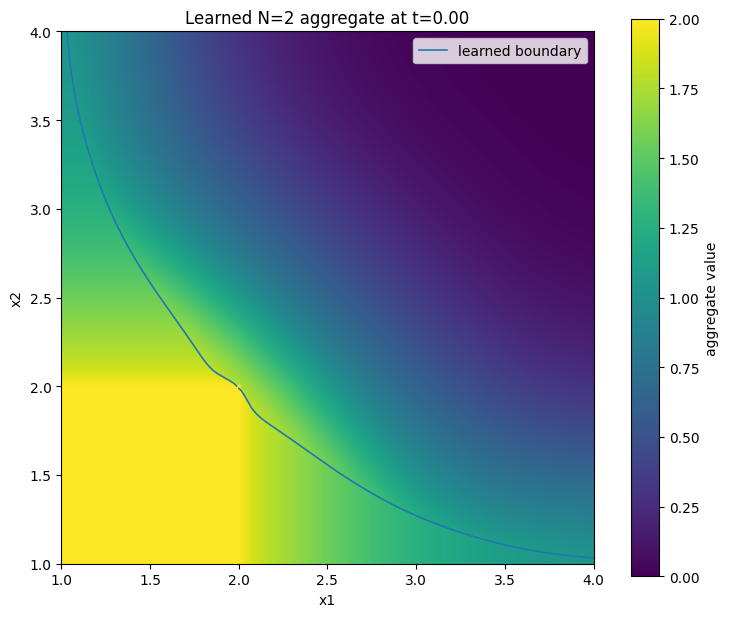

In [ ]:
@torch.no_grad()
def completed_n2_value(
    t: float,
    points: Tensor,
) -> Tensor:
    tt = torch.full(
        (points.shape[0],),
        float(t),
        device=points.device,
        dtype=points.dtype,
    )

    raw = n2_model.value(
        tt,
        points,
    )

    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    threshold = learned_boundary_value(
        tt,
        larger,
    )
    lower_value = learned_singleton_value(
        tt,
        larger,
    )

    in_domain = smaller > threshold

    if abs(t - CFG.T) <= 1.0e-12:
        raw = torch.zeros_like(raw)

    return torch.where(
        in_domain,
        raw,
        lower_value,
    )


@torch.no_grad()
def plot_n2_field(t: float) -> None:
    axis = torch.linspace(
        CFG.x_min,
        CFG.x_max,
        CFG.plot_grid,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(
        axis,
        axis,
        indexing="ij",
    )
    points = torch.stack(
        (x1.reshape(-1), x2.reshape(-1)),
        dim=1,
    )

    field = completed_n2_value(
        t,
        points,
    ).reshape(
        CFG.plot_grid,
        CFG.plot_grid,
    )

    survivor = torch.linspace(
        2.001,
        CFG.x_max,
        600,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = learned_boundary_value(
        t,
        survivor,
    )

    fig, ax = plt.subplots(
        figsize=(7.2, 6.2),
        constrained_layout=True,
    )
    image = ax.imshow(
        tensor_to_numpy(field).T,
        origin="lower",
        extent=[
            CFG.x_min,
            CFG.x_max,
            CFG.x_min,
            CFG.x_max,
        ],
        aspect="equal",
        interpolation="bilinear",
        vmin=0.0,
        vmax=2.0,
    )

    boundary_line, = ax.plot(
        tensor_to_numpy(boundary),
        tensor_to_numpy(survivor),
        linewidth=1.2,
        label="learned boundary",
    )
    ax.plot(
        tensor_to_numpy(survivor),
        tensor_to_numpy(boundary),
        linewidth=1.2,
        color=boundary_line.get_color(),
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(
        f"Learned N=2 aggregate at t={t:.2f}"
    )
    ax.legend()
    fig.colorbar(
        image,
        ax=ax,
        label="aggregate value",
    )

    plt.show()


plot_n2_field(0.0)

### 40-step and 400-step references


In [ ]:
@torch.no_grad()
def exact_boundary_value(
    t: float | Tensor,
    survivor: Tensor,
) -> Tensor:
    return (
        CFG.alpha
        * exact_singleton_value(
            t,
            survivor,
        )
    )


@torch.no_grad()
def exact_n2_in_domain(
    t: float,
    points: Tensor,
) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values

    return (
        smaller
        > exact_boundary_value(
            t,
            larger,
        )
    )


@torch.no_grad()
def reference_payoff_chunk(
    *,
    start_time: float,
    points: Tensor,
    increments: Tensor,
) -> Tensor:
    """Exact-geometry first-exit payoff under a supplied monitoring grid."""
    n_points = points.shape[0]
    n_paths = increments.shape[0]
    n_steps = increments.shape[1]

    dt = (
        CFG.T - start_time
    ) / n_steps

    x = points[:, None, :].expand(
        n_points,
        n_paths,
        2,
    ).clone()

    alive = torch.ones(
        n_points,
        n_paths,
        device=DEVICE,
        dtype=torch.bool,
    )

    payoff = torch.zeros(
        n_points,
        n_paths,
        device=DEVICE,
        dtype=DTYPE,
    )

    for k in range(n_steps + 1):
        current_time = (
            start_time + k * dt
        )

        smaller = x.min(dim=2).values
        larger = x.max(dim=2).values

        threshold = exact_boundary_value(
            current_time,
            larger,
        )

        first_exit = (
            alive
            & (smaller <= threshold)
        )

        if bool(first_exit.any()):
            payoff[first_exit] = (
                exact_singleton_value(
                    current_time,
                    larger[first_exit],
                )
            )
            alive[first_exit] = False

        if k < n_steps:
            x = (
                x
                + CFG.sigma
                * increments[:, k][None, :, :]
            )

    return payoff


@torch.no_grad()
def coupled_reference_increments() -> tuple[Tensor, Tensor, int]:
    """Couple the 40-step and 400-step references on the same Brownian paths."""
    coarse = CFG.reference_coarse_steps
    fine = CFG.reference_fine_steps

    if fine % coarse != 0:
        raise ValueError(
            "reference_fine_steps must be an integer multiple of "
            "reference_coarse_steps"
        )
    if CFG.reference_paths % 2 != 0:
        raise ValueError(
            "reference_paths must be even for antithetic pairing"
        )

    half = CFG.reference_paths // 2
    generator = make_generator(
        SEED + 10_000
    )

    half_normals = torch.randn(
        half,
        fine,
        2,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )
    normals = torch.cat(
        (half_normals, -half_normals),
        dim=0,
    )

    fine_dt = CFG.T / fine
    fine_dW = math.sqrt(fine_dt) * normals

    block = fine // coarse
    coarse_dW = (
        fine_dW.reshape(
            CFG.reference_paths,
            coarse,
            block,
            2,
        )
        .sum(dim=2)
    )

    return coarse_dW, fine_dW, half


@torch.no_grad()
def reference_field_from_increments(
    *,
    points: Tensor,
    in_domain: Tensor,
    increments: Tensor,
    antithetic_half: int,
) -> tuple[Tensor, Tensor]:
    reference = exact_singleton_value(
        0.0,
        points.max(dim=1).values,
    )
    reference_se = torch.zeros_like(
        reference
    )

    inside_points = points[
        in_domain
    ]

    estimates = []
    standard_errors = []

    for start in range(
        0,
        len(inside_points),
        CFG.reference_point_batch,
    ):
        chunk = inside_points[
            start:
            start + CFG.reference_point_batch
        ]

        samples = reference_payoff_chunk(
            start_time=0.0,
            points=chunk,
            increments=increments,
        )

        pair_mean = 0.5 * (
            samples[:, :antithetic_half]
            + samples[:, antithetic_half:]
        )

        estimates.append(
            pair_mean.mean(dim=1)
        )
        standard_errors.append(
            pair_mean.std(
                dim=1,
                unbiased=True,
            ) / math.sqrt(antithetic_half)
        )

    reference[in_domain] = torch.cat(
        estimates
    )
    reference_se[in_domain] = torch.cat(
        standard_errors
    )

    return reference, reference_se


def reference_metrics(
    *,
    learned: Tensor,
    reference: Tensor,
    reference_se: Tensor,
    in_domain: Tensor,
) -> dict[str, float]:
    error = (
        learned[in_domain]
        - reference[in_domain]
    )

    return {
        "field_MAE": float(
            error.abs().mean().cpu()
        ),
        "field_RMSE": float(
            torch.sqrt(
                error.square().mean()
            ).cpu()
        ),
        "field_max_error": float(
            error.abs().max().cpu()
        ),
        "reference_mean_MC_SE": float(
            reference_se[in_domain].mean().cpu()
        ),
        "reference_max_MC_SE": float(
            reference_se[in_domain].max().cpu()
        ),
    }


@torch.no_grad()
def independent_reference_t0_coupled():
    axis = torch.linspace(
        CFG.x_min,
        CFG.x_max,
        CFG.reference_grid,
        device=DEVICE,
        dtype=DTYPE,
    )

    x1, x2 = torch.meshgrid(
        axis,
        axis,
        indexing="ij",
    )

    points = torch.stack(
        (x1.reshape(-1), x2.reshape(-1)),
        dim=1,
    )

    in_domain = exact_n2_in_domain(
        0.0,
        points,
    )

    learned = completed_n2_value(
        0.0,
        points,
    )

    coarse_dW, fine_dW, half = (
        coupled_reference_increments()
    )

    reference_40, se_40 = (
        reference_field_from_increments(
            points=points,
            in_domain=in_domain,
            increments=coarse_dW,
            antithetic_half=half,
        )
    )

    reference_400, se_400 = (
        reference_field_from_increments(
            points=points,
            in_domain=in_domain,
            increments=fine_dW,
            antithetic_half=half,
        )
    )

    metrics_40 = reference_metrics(
        learned=learned,
        reference=reference_40,
        reference_se=se_40,
        in_domain=in_domain,
    )
    metrics_400 = reference_metrics(
        learned=learned,
        reference=reference_400,
        reference_se=se_400,
        in_domain=in_domain,
    )

    monitoring_difference = (
        reference_40[in_domain]
        - reference_400[in_domain]
    )

    sensitivity = {
        "reference_40_vs_400_MAE": float(
            monitoring_difference.abs().mean().cpu()
        ),
        "reference_40_vs_400_RMSE": float(
            torch.sqrt(
                monitoring_difference.square().mean()
            ).cpu()
        ),
        "reference_40_vs_400_max_error": float(
            monitoring_difference.abs().max().cpu()
        ),
    }

    return {
        "axis": axis,
        "points": points,
        "in_domain": in_domain,
        "learned": learned,
        "reference_40": reference_40,
        "reference_400": reference_400,
        "se_40": se_40,
        "se_400": se_400,
        "metrics_40": metrics_40,
        "metrics_400": metrics_400,
        "sensitivity": sensitivity,
    }


reference_bundle = independent_reference_t0_coupled()

reference_axis = reference_bundle["axis"]
reference_points = reference_bundle["points"]
reference_in_domain = reference_bundle["in_domain"]
learned_field = reference_bundle["learned"]

reference_field_40 = reference_bundle["reference_40"]
reference_field_400 = reference_bundle["reference_400"]
reference_standard_error_40 = reference_bundle["se_40"]
reference_standard_error_400 = reference_bundle["se_400"]

n2_reference_metrics_40 = reference_bundle["metrics_40"]
n2_reference_metrics_400 = reference_bundle["metrics_400"]
n2_reference_monitoring_sensitivity = reference_bundle["sensitivity"]

# Use the 400-step reference as the main reference.
reference_field = reference_field_400
reference_standard_error = reference_standard_error_400
n2_reference_metrics = n2_reference_metrics_400

reference_comparison_table = pd.DataFrame(
    [
        {
            "reference_steps": CFG.reference_coarse_steps,
            **n2_reference_metrics_40,
        },
        {
            "reference_steps": CFG.reference_fine_steps,
            **n2_reference_metrics_400,
        },
    ]
)
monitoring_sensitivity_table = pd.DataFrame(
    [n2_reference_monitoring_sensitivity]
)



show_table(
    reference_comparison_table,
    "Coupled N=2 exact-geometry references at 40 and 400 monitoring intervals",
)
show_table(
    monitoring_sensitivity_table,
    "N=2 monitoring-grid sensitivity of the exact-geometry reference",
)


#### Coupled N=2 exact-geometry references at 40 and 400 monitoring intervals

reference_steps,Field MAE,Field RMSE,Field maximum error,Mean Monte Carlo SE,Maximum Monte Carlo SE
40.000000,0.037605,0.042646,0.095018,0.009713,0.013614
400.000000,0.073054,0.081816,0.178321,0.009531,0.013395


#### N=2 monitoring-grid sensitivity of the exact-geometry reference

reference_40_vs_400_MAE,reference_40_vs_400_RMSE,reference_40_vs_400_max_error
0.040637,0.047693,0.160448


### N=2 reference comparison


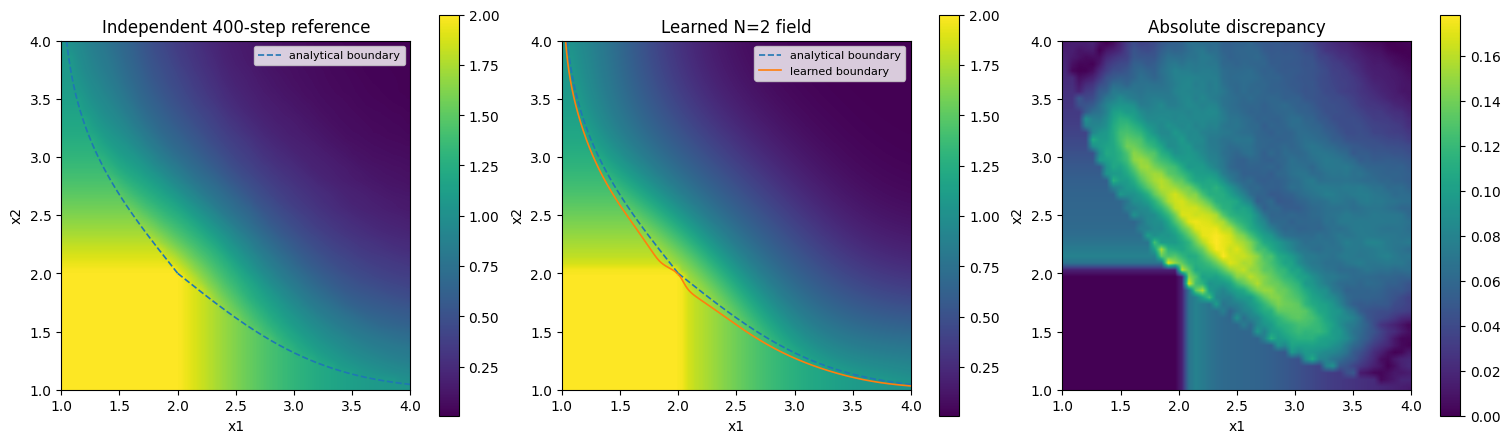

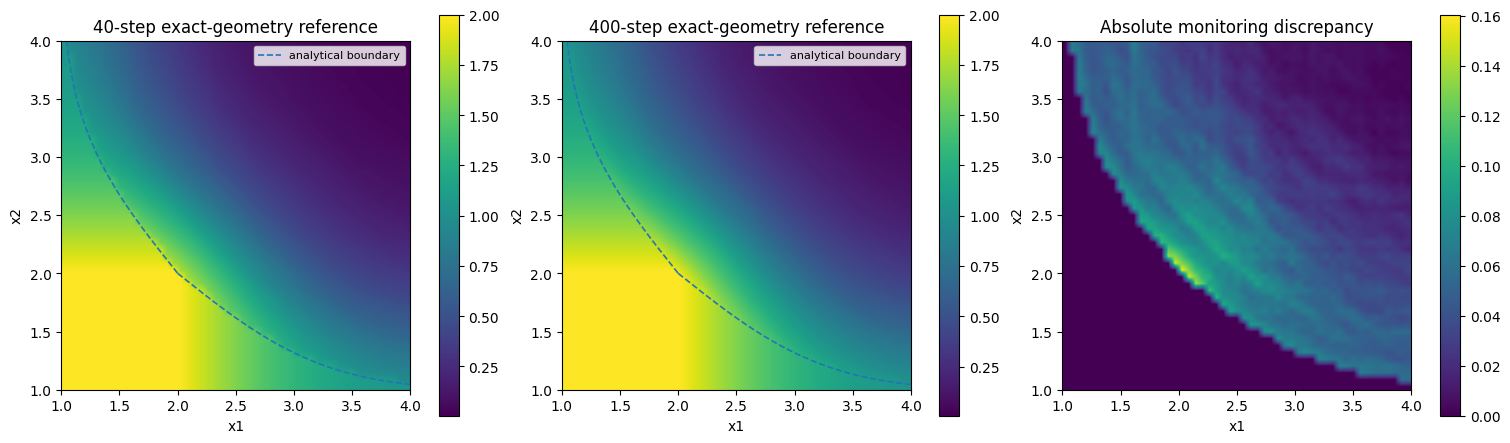

In [ ]:
reference_array = tensor_to_numpy(
    reference_field_400
).reshape(
    CFG.reference_grid,
    CFG.reference_grid,
)

reference_40_array = tensor_to_numpy(
    reference_field_40
).reshape(
    CFG.reference_grid,
    CFG.reference_grid,
)

learned_array = tensor_to_numpy(
    learned_field
).reshape(
    CFG.reference_grid,
    CFG.reference_grid,
)

discrepancy_array = np.abs(
    learned_array - reference_array
)

monitoring_discrepancy_array = np.abs(
    reference_40_array - reference_array
)

axis_np = tensor_to_numpy(
    reference_axis
)

survivor = torch.linspace(
    2.001,
    CFG.x_max,
    600,
    device=DEVICE,
    dtype=DTYPE,
)

exact_boundary = exact_boundary_value(
    0.0,
    survivor,
)
learned_boundary = learned_boundary_value(
    0.0,
    survivor,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.0, 4.8),
    constrained_layout=True,
)

for ax, values, title in (
    (
        axes[0],
        reference_array,
        "Independent 400-step reference",
    ),
    (
        axes[1],
        learned_array,
        "Learned N=2 field",
    ),
    (
        axes[2],
        discrepancy_array,
        "Absolute discrepancy",
    ),
):
    image = ax.imshow(
        values.T,
        origin="lower",
        extent=[
            axis_np[0],
            axis_np[-1],
            axis_np[0],
            axis_np[-1],
        ],
        aspect="equal",
        interpolation="bilinear",
    )

    if title != "Absolute discrepancy":
        exact_line, = ax.plot(
            tensor_to_numpy(
                exact_boundary
            ),
            tensor_to_numpy(
                survivor
            ),
            linestyle="--",
            linewidth=1.2,
            label="analytical boundary",
        )
        ax.plot(
            tensor_to_numpy(
                survivor
            ),
            tensor_to_numpy(
                exact_boundary
            ),
            linestyle="--",
            linewidth=1.2,
            color=exact_line.get_color(),
        )

        if title == "Learned N=2 field":
            learned_line, = ax.plot(
                tensor_to_numpy(
                    learned_boundary
                ),
                tensor_to_numpy(
                    survivor
                ),
                linewidth=1.2,
                label="learned boundary",
            )
            ax.plot(
                tensor_to_numpy(
                    survivor
                ),
                tensor_to_numpy(
                    learned_boundary
                ),
                linewidth=1.2,
                color=learned_line.get_color(),
            )

        ax.legend(fontsize=8)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    fig.colorbar(
        image,
        ax=ax,
        shrink=0.85,
    )

plt.show()


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15.0, 4.8),
    constrained_layout=True,
)

for ax, values, title in (
    (
        axes[0],
        reference_40_array,
        "40-step exact-geometry reference",
    ),
    (
        axes[1],
        reference_array,
        "400-step exact-geometry reference",
    ),
    (
        axes[2],
        monitoring_discrepancy_array,
        "Absolute monitoring discrepancy",
    ),
):
    image = ax.imshow(
        values.T,
        origin="lower",
        extent=[
            axis_np[0],
            axis_np[-1],
            axis_np[0],
            axis_np[-1],
        ],
        aspect="equal",
        interpolation="bilinear",
    )

    if title != "Absolute monitoring discrepancy":
        line, = ax.plot(
            tensor_to_numpy(exact_boundary),
            tensor_to_numpy(survivor),
            linestyle="--",
            linewidth=1.2,
            label="analytical boundary",
        )
        ax.plot(
            tensor_to_numpy(survivor),
            tensor_to_numpy(exact_boundary),
            linestyle="--",
            linewidth=1.2,
            color=line.get_color(),
        )
        ax.legend(fontsize=8)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    fig.colorbar(
        image,
        ax=ax,
        shrink=0.85,
    )

plt.show()


## 3. Homogeneous cascade


### Symmetric neural architectures


In [ ]:
def symmetric_statistics(
    x: Tensor,
    number: int,
) -> Tensor:
    mean = x.mean(
        dim=1,
        keepdim=True,
    )

    if number == 1:
        return mean

    centred = x - mean
    features = [mean]

    for power in range(
        2,
        number + 1,
    ):
        features.append(
            centred.pow(power).mean(
                dim=1,
                keepdim=True,
            )
        )

    return torch.cat(
        features,
        dim=1,
    )


class GeneralSingletonFBSDE(nn.Module):
    def __init__(
        self,
        total_particles: int,
    ) -> None:
        super().__init__()

        self.total_particles = total_particles
        threshold = (
            CFG.alpha * total_particles
        )
        x_high = max(
            CFG.x_max,
            threshold + 2.0,
        )

        x_center = 0.5 * (
            threshold + x_high
        )
        x_scale = 0.5 * (
            x_high - threshold
        )

        self.value_net = NormalisedMLP(
            2,
            1,
            CFG.width,
            CFG.depth,
            center=(0.5, x_center),
            scale=(0.5, x_scale),
        )
        self.z_net = NormalisedMLP(
            2,
            1,
            CFG.width,
            CFG.depth,
            center=(0.5, x_center),
            scale=(0.5, x_scale),
        )

    def value(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        x = x.reshape(-1)

        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        raw = self.value_net(
            torch.cat(
                (tc, x[:, None]),
                dim=1,
            )
        )[:, 0]

        return (
            float(
                self.total_particles - 1
            )
            + torch.sigmoid(raw)
        )

    def z(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        x = x.reshape(-1)

        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        return self.z_net(
            torch.cat(
                (tc, x[:, None]),
                dim=1,
            )
        )[:, 0]



class GeneralTwoParticleFBSDE(nn.Module):
    """Symmetric two-coordinate architecture used inside a general cascade."""

    def __init__(
        self,
        total_particles: int,
    ) -> None:
        super().__init__()

        x_high = max(
            CFG.x_max,
            CFG.alpha
            * total_particles
            + 2.0,
        )

        x_center = 0.5 * (
            CFG.x_min + x_high
        )
        x_scale = 0.5 * (
            x_high - CFG.x_min
        )

        self.value_net = NormalisedMLP(
            3,
            1,
            CFG.width,
            CFG.depth,
            center=(
                0.5,
                x_center,
                0.5 * x_scale**2,
            ),
            scale=(
                0.5,
                x_scale,
                0.5 * x_scale**2,
            ),
        )

        self.z_component_net = NormalisedMLP(
            3,
            1,
            CFG.width,
            CFG.depth,
            center=(
                0.5,
                x_center,
                x_center,
            ),
            scale=(
                0.5,
                x_scale,
                x_scale,
            ),
        )

    def value(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        mean = x.mean(
            dim=1,
            keepdim=True,
        )

        variance = 0.25 * (
            x[:, 0:1]
            - x[:, 1:2]
        ).square()

        return self.value_net(
            torch.cat(
                (
                    tc,
                    mean,
                    variance,
                ),
                dim=1,
            )
        )[:, 0]

    def z(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        z1 = self.z_component_net(
            torch.cat(
                (
                    tc,
                    x[:, 0:1],
                    x[:, 1:2],
                ),
                dim=1,
            )
        )

        z2 = self.z_component_net(
            torch.cat(
                (
                    tc,
                    x[:, 1:2],
                    x[:, 0:1],
                ),
                dim=1,
            )
        )

        return torch.cat(
            (z1, z2),
            dim=1,
        )


class HigherSymmetricFBSDE(nn.Module):
    def __init__(
        self,
        total_particles: int,
        alive_particles: int,
    ) -> None:
        super().__init__()

        if alive_particles < 3:
            raise ValueError(
                "HigherSymmetricFBSDE is for m>=3"
            )

        self.total_particles = total_particles
        self.alive_particles = alive_particles

        x_high = max(
            CFG.x_max,
            CFG.alpha
            * total_particles
            + 2.0,
        )

        x_center = 0.5 * (
            CFG.x_min + x_high
        )
        x_scale = 0.5 * (
            x_high - CFG.x_min
        )

        value_center = [
            0.5,
            x_center,
        ]
        value_scale = [
            0.5,
            x_scale,
        ]

        for power in range(
            2,
            alive_particles + 1,
        ):
            value_center.append(0.0)
            value_scale.append(
                max(
                    1.0,
                    x_scale ** power,
                )
            )

        self.value_net = NormalisedMLP(
            1 + alive_particles,
            1,
            CFG.width,
            CFG.depth,
            center=tuple(value_center),
            scale=tuple(value_scale),
        )

        remaining = alive_particles - 1

        z_center = [
            0.5,
            x_center,
            x_center,
        ]
        z_scale = [
            0.5,
            x_scale,
            x_scale,
        ]

        for power in range(
            2,
            remaining + 1,
        ):
            z_center.append(0.0)
            z_scale.append(
                max(
                    1.0,
                    x_scale ** power,
                )
            )

        self.z_component_net = NormalisedMLP(
            len(z_center),
            1,
            CFG.width,
            CFG.depth,
            center=tuple(z_center),
            scale=tuple(z_scale),
        )

    def value(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        statistics = symmetric_statistics(
            x,
            self.alive_particles,
        )

        return self.value_net(
            torch.cat(
                (tc, statistics),
                dim=1,
            )
        )[:, 0]

    def z(
        self,
        t: float | Tensor,
        x: Tensor,
    ) -> Tensor:
        tc = time_column(
            t,
            x.shape[0],
            device=x.device,
            dtype=x.dtype,
        )

        components = []

        for j in range(
            self.alive_particles
        ):
            own = x[:, j:j + 1]

            remaining = torch.cat(
                (
                    x[:, :j],
                    x[:, j + 1:],
                ),
                dim=1,
            )

            remaining_statistics = (
                symmetric_statistics(
                    remaining,
                    self.alive_particles - 1,
                )
            )

            features = torch.cat(
                (
                    tc,
                    own,
                    remaining_statistics,
                ),
                dim=1,
            )

            components.append(
                self.z_component_net(
                    features
                )[:, 0]
            )

        return torch.stack(
            components,
            dim=1,
        )

### Completion and stopping


In [ ]:
@torch.no_grad()
def completed_value(
    total_particles: int,
    alive_particles: int,
    t: float | Tensor,
    x: Tensor,
    models: dict[int, nn.Module],
) -> Tensor:
    if alive_particles == 0:
        return torch.full(
            (x.shape[0],),
            float(total_particles),
            device=x.device,
            dtype=x.dtype,
        )

    if alive_particles == 1:
        raw = models[1].value(
            t,
            x[:, 0],
        )

        threshold = (
            CFG.alpha
            * total_particles
        )

        return torch.where(
            x[:, 0] <= threshold,
            torch.full_like(
                raw,
                float(total_particles),
            ),
            raw,
        )

    raw = models[
        alive_particles
    ].value(
        t,
        x,
    )

    lower_values = []
    margins = []

    for i in range(
        alive_particles
    ):
        reduced = torch.cat(
            (
                x[:, :i],
                x[:, i + 1:],
            ),
            dim=1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            t,
            reduced,
            models,
        )

        lower_values.append(
            lower
        )

        margins.append(
            x[:, i]
            - CFG.alpha * lower
        )

    lower_values = torch.stack(
        lower_values,
        dim=1,
    )

    margins = torch.stack(
        margins,
        dim=1,
    )

    in_domain = (
        margins > 0.0
    ).all(dim=1)

    selected = margins.argmin(
        dim=1
    )

    boundary_value = (
        lower_values.gather(
            1,
            selected[:, None],
        )[:, 0]
    )

    tt = torch.as_tensor(
        t,
        device=x.device,
        dtype=x.dtype,
    )

    if tt.ndim == 0:
        tt = tt.expand(
            x.shape[0]
        )

    terminal_value = torch.full_like(
        raw,
        float(
            total_particles
            - alive_particles
        ),
    )

    raw = torch.where(
        tt >= CFG.T - 1.0e-10,
        terminal_value,
        raw,
    )

    return torch.where(
        in_domain,
        raw,
        boundary_value,
    )


@torch.no_grad()
def level_stop_target(
    total_particles: int,
    alive_particles: int,
    batch: BrownianBatch,
    lower_models: dict[int, nn.Module],
):
    batch_size, time_count, _ = (
        batch.paths.shape
    )

    lower_values = []
    margins = []

    flat_time = batch.times.reshape(
        -1
    )

    for i in range(
        alive_particles
    ):
        reduced = torch.cat(
            (
                batch.paths[:, :, :i],
                batch.paths[:, :, i + 1:],
            ),
            dim=2,
        ).reshape(
            -1,
            alive_particles - 1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            flat_time,
            reduced,
            lower_models,
        ).reshape(
            batch_size,
            time_count,
        )

        lower_values.append(
            lower
        )

        margins.append(
            batch.paths[:, :, i]
            - CFG.alpha * lower
        )

    lower_values = torch.stack(
        lower_values,
        dim=2,
    )

    margins = torch.stack(
        margins,
        dim=2,
    )

    outside_domain = (
        margins <= 0.0
    ).any(dim=2)

    stop_index, hit = (
        first_true_index(
            outside_domain
        )
    )

    row = torch.arange(
        batch_size,
        device=DEVICE,
    )

    stopped_margins = margins[
        row,
        stop_index,
    ]

    stopped_lower = lower_values[
        row,
        stop_index,
    ]

    selected = stopped_margins.argmin(
        dim=1
    )

    exit_value = (
        stopped_lower.gather(
            1,
            selected[:, None],
        )[:, 0]
    )

    terminal_value = torch.full_like(
        exit_value,
        float(
            total_particles
            - alive_particles
        ),
    )

    target = torch.where(
        hit,
        exit_value,
        terminal_value,
    )

    return stop_index, target, hit

### Loss functions


In [ ]:
def forward_generic_level(
    model: nn.Module,
    batch: BrownianBatch,
    stop_index: Tensor,
    alive_particles: int,
) -> Tensor:
    if alive_particles == 1:
        y = model.value(
            batch.start_time,
            batch.x0[:, 0],
        )
    else:
        y = model.value(
            batch.start_time,
            batch.x0,
        )

    for k in range(
        batch.dW.shape[1]
    ):
        before_exit = (
            stop_index > k
        ).to(DTYPE)

        if alive_particles == 1:
            z = model.z(
                batch.times[:, k],
                batch.paths[:, k, 0],
            )
            increment = (
                z
                * batch.dW[:, k, 0]
            )
        else:
            z = model.z(
                batch.times[:, k],
                batch.paths[:, k],
            )
            increment = (
                z
                * batch.dW[:, k]
            ).sum(dim=1)

        y = y + (
            before_exit
            * increment
        )

    return y


def generic_configuration_losses(
    model: nn.Module,
    batch: BrownianBatch,
    stop_index: Tensor,
    stop_target: Tensor,
    hit: Tensor,
    alive_particles: int,
) -> tuple[Tensor, Tensor]:
    def value_function(t, x):
        if alive_particles == 1:
            return model.value(
                t,
                x[:, 0],
            )
        return model.value(t, x)

    def z_function(t, x):
        if alive_particles == 1:
            return model.z(
                t,
                x[:, 0],
            )
        return model.z(t, x)

    return local_configuration_losses(
        value_function=value_function,
        z_function=z_function,
        batch=batch,
        stop_index=stop_index,
        stop_target=stop_target,
        hit=hit,
    )


@torch.no_grad()
def lower_domain_mask(
    total_particles: int,
    alive_particles: int,
    t: Tensor,
    x: Tensor,
    models: dict[int, nn.Module],
) -> Tensor:
    if alive_particles == 1:
        return (
            x[:, 0]
            > CFG.alpha
            * total_particles
        )

    margins = []

    for i in range(
        alive_particles
    ):
        reduced = torch.cat(
            (
                x[:, :i],
                x[:, i + 1:],
            ),
            dim=1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            t,
            reduced,
            models,
        )

        margins.append(
            x[:, i]
            - CFG.alpha * lower
        )

    return (
        torch.stack(
            margins,
            dim=1,
        )
        > 0.0
    ).all(dim=1)



@torch.no_grad()
def current_level_margins(
    total_particles: int,
    alive_particles: int,
    t: Tensor,
    points: Tensor,
    lower_models: dict[int, nn.Module],
) -> Tensor:
    """Margins of the current level against the frozen completed lower field."""
    if alive_particles == 1:
        return (
            points[:, 0:1]
            - CFG.alpha * total_particles
        )

    margins = []

    for i in range(alive_particles):
        reduced = torch.cat(
            (
                points[:, :i],
                points[:, i + 1:],
            ),
            dim=1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            t,
            reduced,
            lower_models,
        )

        margins.append(
            points[:, i]
            - CFG.alpha * lower
        )

    return torch.stack(
        margins,
        dim=1,
    )


@torch.no_grad()
def sample_generic_boundary_data(
    total_particles: int,
    alive_particles: int,
    models: dict[int, nn.Module],
    generator: torch.Generator,
    size: int,
):
    """Sample regular boundary-face points of the learned current domain.

    A designated coordinate is placed exactly on its frozen lower-level
    boundary.  The proposal is accepted only if every other current-level
    margin remains strictly positive.  This avoids using points that belong
    to a different face, or to an approximate multiple-exit intersection,
    as single-face boundary collocation data.
    """
    if alive_particles < 2:
        raise ValueError(
            "Generic boundary sampling is for levels with at least two living coordinates"
        )

    x_high = max(
        CFG.x_max,
        CFG.alpha
        * total_particles
        + 2.0,
    )

    accepted_t = []
    accepted_point = []
    accepted_target = []
    needed = size

    for _ in range(
        CFG.boundary_sampling_rounds
    ):
        if needed <= 0:
            break

        proposal = max(
            CFG.boundary_proposal_multiplier
            * needed,
            128,
        )

        proposal_t = (
            stratified_restart_times(
                proposal,
                CFG,
                generator,
            )
        )

        survivor = uniform(
            (
                proposal,
                alive_particles - 1,
            ),
            CFG.x_min,
            x_high,
            generator,
        )

        lower_valid = lower_domain_mask(
            total_particles,
            alive_particles - 1,
            proposal_t,
            survivor,
            models,
        )

        if not bool(lower_valid.any()):
            continue

        proposal_t = proposal_t[
            lower_valid
        ]
        survivor = survivor[
            lower_valid
        ]

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            proposal_t,
            survivor,
            models,
        )

        boundary_coordinate = (
            CFG.alpha * lower
        )[:, None]

        point = torch.cat(
            (
                boundary_coordinate,
                survivor,
            ),
            dim=1,
        )

        margins = current_level_margins(
            total_particles,
            alive_particles,
            proposal_t,
            point,
            models,
        )

        designated_face = (
            margins[:, 0].abs()
            <= CFG.boundary_zero_tolerance
        )

        other_margins_valid = (
            margins[:, 1:]
            > CFG.boundary_other_margin
        ).all(dim=1)

        valid = (
            designated_face
            & other_margins_valid
        )

        if not bool(valid.any()):
            continue

        rows = valid.nonzero(
            as_tuple=False
        ).flatten()[:needed]

        accepted_t.append(
            proposal_t[rows]
        )
        accepted_point.append(
            point[rows]
        )
        accepted_target.append(
            lower[rows]
        )
        needed -= len(rows)

    if needed > 0:
        raise RuntimeError(
            "Could not sample enough regular current-level boundary-face points. "
            "Reduce boundary_other_margin or enlarge the state box."
        )

    t = torch.cat(
        accepted_t,
        dim=0,
    )[:size]

    point = torch.cat(
        accepted_point,
        dim=0,
    )[:size]

    target = torch.cat(
        accepted_target,
        dim=0,
    )[:size]

    # Randomly place the boundary coordinate.
    permutation_keys = torch.rand(
        size,
        alive_particles,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )
    permutations = permutation_keys.argsort(
        dim=1
    )
    point = point.gather(
        1,
        permutations,
    )

    # Check one zero margin and all other margins are positive.
    margins = current_level_margins(
        total_particles,
        alive_particles,
        t,
        point,
        models,
    )
    near_zero = (
        margins.abs()
        <= CFG.boundary_zero_tolerance
    )
    if not bool(
        (
            near_zero.sum(dim=1) == 1
        ).all()
    ):
        raise AssertionError(
            "Strict boundary sampler did not produce exactly one designated face"
        )

    positive_other = torch.where(
        near_zero,
        torch.full_like(
            margins,
            math.inf,
        ),
        margins,
    ).min(dim=1).values

    if not bool(
        (
            positive_other
            > CFG.boundary_other_margin
        ).all()
    ):
        raise AssertionError(
            "Strict boundary sampler produced a non-positive non-designated margin"
        )

    return (
        t,
        point,
        target,
    )


@torch.no_grad()
def generic_terminal_mask(
    total_particles: int,
    alive_particles: int,
    points: Tensor,
    lower_models: dict[int, nn.Module],
) -> Tensor:
    batch_size = points.shape[0]

    time = torch.full(
        (batch_size, 1),
        CFG.T,
        device=DEVICE,
        dtype=DTYPE,
    )

    paths = points[:, None, :]

    margins = []

    for i in range(
        alive_particles
    ):
        reduced = torch.cat(
            (
                paths[:, :, :i],
                paths[:, :, i + 1:],
            ),
            dim=2,
        ).reshape(
            batch_size,
            alive_particles - 1,
        )

        lower = completed_value(
            total_particles,
            alive_particles - 1,
            time[:, 0],
            reduced,
            lower_models,
        )

        margins.append(
            points[:, i]
            - CFG.alpha * lower
        )

    margins = torch.stack(
        margins,
        dim=1,
    )

    return (
        margins > 0.0
    ).all(dim=1)


def aggregate_range_loss(
    prediction: Tensor,
    lower: float,
    upper: float,
) -> Tensor:
    return (
        torch.relu(
            lower - prediction
        ).square().mean()
        +
        torch.relu(
            prediction - upper
        ).square().mean()
    )


def generic_level_data(
    total_particles: int,
    alive_particles: int,
    models: dict[int, nn.Module],
    *,
    batch_size: int,
    generator: torch.Generator,
    antithetic: bool,
):
    x_high = max(
        CFG.x_max,
        CFG.alpha
        * total_particles
        + 2.0,
    )

    batch = sample_brownian_batch(
        batch_size=batch_size,
        dimension=alive_particles,
        x_min=CFG.x_min,
        x_max=x_high,
        cfg=CFG,
        generator=generator,
        antithetic=antithetic,
    )

    boundary_data = (
        sample_generic_boundary_data(
            total_particles,
            alive_particles,
            models,
            generator,
            batch_size,
        )
    )

    terminal_points = uniform(
        (
            batch_size,
            alive_particles,
        ),
        CFG.x_min,
        x_high,
        generator,
    )

    range_time = (
        stratified_restart_times(
            batch_size,
            CFG,
            generator,
        )
    )

    range_points = uniform(
        (
            batch_size,
            alive_particles,
        ),
        CFG.x_min,
        x_high,
        generator,
    )

    return (
        batch,
        boundary_data,
        terminal_points,
        range_time,
        range_points,
    )


def generic_level_loss(
    total_particles: int,
    alive_particles: int,
    model: nn.Module,
    lower_models: dict[int, nn.Module],
    data,
):
    (
        batch,
        boundary_data,
        terminal_points,
        range_time,
        range_points,
    ) = data

    with torch.no_grad():
        (
            stop_index,
            stop_target,
            hit,
        ) = level_stop_target(
            total_particles,
            alive_particles,
            batch,
            lower_models,
        )

    stopped_y = forward_generic_level(
        model,
        batch,
        stop_index,
        alive_particles,
    )

    stopped_loss = (
        stopped_y
        - stop_target
    ).square().mean()

    alive_loss, exit_loss = (
        generic_configuration_losses(
            model,
            batch,
            stop_index,
            stop_target,
            hit,
            alive_particles,
        )
    )

    (
        boundary_time,
        boundary_points,
        boundary_target,
    ) = boundary_data

    boundary_prediction = model.value(
        boundary_time,
        boundary_points,
    )

    boundary_loss = (
        boundary_prediction
        - boundary_target
    ).square().mean()

    with torch.no_grad():
        terminal_mask = (
            generic_terminal_mask(
                total_particles,
                alive_particles,
                terminal_points,
                lower_models,
            )
        )

    terminal_prediction = model.value(
        CFG.T,
        terminal_points,
    )

    terminal_value = float(
        total_particles
        - alive_particles
    )

    terminal_loss = masked_mean(
        (
            terminal_prediction
            - terminal_value
        ).square(),
        terminal_mask,
    )

    with torch.no_grad():
        range_in_domain = lower_domain_mask(
            total_particles,
            alive_particles,
            range_time,
            range_points,
            lower_models,
        )

    range_prediction = model.value(
        range_time,
        range_points,
    )

    range_penalty = (
        torch.relu(
            float(
                total_particles
                - alive_particles
            )
            - range_prediction
        ).square()
        +
        torch.relu(
            range_prediction
            - float(total_particles)
        ).square()
    )

    range_loss = masked_mean(
        range_penalty,
        range_in_domain,
    )

    total = (
        stopped_loss
        + CFG.alive_state_weight
        * alive_loss
        + CFG.exit_step_weight
        * exit_loss
        + boundary_loss
        + terminal_loss
        + CFG.higher_range_weight * range_loss
    )

    return total, {
        "stopped": stopped_loss,
        "alive": alive_loss,
        "exit": exit_loss,
        "boundary": boundary_loss,
        "terminal": terminal_loss,
        "range": range_loss,
    }

### Cascade training


In [ ]:
def train_general_singleton(
    total_particles: int,
    seed: int,
):
    model = GeneralSingletonFBSDE(
        total_particles
    ).to(DEVICE)

    threshold = (
        CFG.alpha
        * total_particles
    )

    x_high = max(
        CFG.x_max,
        threshold + 2.0,
    )

    train_generator = (
        make_generator(seed + 1)
    )
    validation_generator = (
        make_generator(seed + 2)
    )

    def sample_data(
        batch_size: int,
        generator: torch.Generator,
        antithetic: bool,
    ):
        batch = sample_brownian_batch(
            batch_size=batch_size,
            dimension=1,
            x_min=threshold + 0.001,
            x_max=x_high,
            cfg=CFG,
            generator=generator,
            antithetic=antithetic,
        )

        boundary_time = (
            stratified_restart_times(
                batch_size,
                CFG,
                generator,
            )
        )

        terminal_x = uniform(
            (batch_size,),
            threshold + 0.001,
            x_high,
            generator,
        )

        noninc_time = (
            stratified_restart_times(
                batch_size,
                CFG,
                generator,
            )
        )

        noninc_x = uniform(
            (batch_size,),
            threshold + 0.001,
            x_high,
            generator,
        )

        return (
            batch,
            boundary_time,
            terminal_x,
            noninc_time,
            noninc_x,
        )

    validation_data = sample_data(
        CFG.validation_size,
        validation_generator,
        False,
    )

    def objective(
        current_model,
        data,
    ):
        (
            batch,
            boundary_time,
            terminal_x,
            noninc_time,
            noninc_x,
        ) = data

        outside_domain = (
            batch.paths[:, :, 0]
            <= threshold
        )

        stop_index, hit = (
            first_true_index(
                outside_domain
            )
        )

        target = torch.where(
            hit,
            torch.full_like(
                batch.start_time,
                float(total_particles),
            ),
            torch.full_like(
                batch.start_time,
                float(
                    total_particles - 1
                ),
            ),
        )

        stopped_y = forward_generic_level(
            current_model,
            batch,
            stop_index,
            1,
        )

        stopped_loss = (
            stopped_y - target
        ).square().mean()

        alive_loss, exit_loss = (
            generic_configuration_losses(
                current_model,
                batch,
                stop_index,
                target,
                hit,
                1,
            )
        )

        boundary_prediction = (
            current_model.value(
                boundary_time,
                torch.full_like(
                    boundary_time,
                    threshold,
                ),
            )
        )

        boundary_loss = (
            boundary_prediction
            - float(total_particles)
        ).square().mean()

        terminal_prediction = (
            current_model.value(
                CFG.T,
                terminal_x,
            )
        )

        terminal_loss = (
            terminal_prediction
            - float(
                total_particles - 1
            )
        ).square().mean()

        noninc_x_grad = (
            noninc_x.detach()
            .clone()
            .requires_grad_(True)
        )

        noninc_value = (
            current_model.value(
                noninc_time,
                noninc_x_grad,
            )
        )

        derivative = torch.autograd.grad(
            noninc_value.sum(),
            noninc_x_grad,
            create_graph=True,
        )[0]

        noninc_loss = (
            torch.relu(
                derivative
            ).square().mean()
        )

        total = (
            stopped_loss
            + CFG.alive_state_weight
            * alive_loss
            + CFG.exit_step_weight
            * exit_loss
            + boundary_loss
            + terminal_loss
            + CFG.singleton_nonincreasing_weight
            * noninc_loss
        )

        return total, {
            "stopped": stopped_loss,
            "alive": alive_loss,
            "exit": exit_loss,
            "boundary": boundary_loss,
            "terminal": terminal_loss,
            "noninc": noninc_loss,
        }

    def train_objective(
        current_model,
    ):
        return objective(
            current_model,
            sample_data(
                CFG.batch_size,
                train_generator,
                True,
            ),
        )

    def validation_objective(
        current_model,
    ):
        return objective(
            current_model,
            validation_data,
        )

    training = train(
        model=model,
        name=f"N{total_particles}_level1",
        train_objective=train_objective,
        validation_objective=validation_objective,
        iterations=CFG.iterations_singleton,
        cfg=CFG,
    )

    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    return model, training


def train_general_level(
    total_particles: int,
    alive_particles: int,
    models: dict[int, nn.Module],
    seed: int,
):
    if alive_particles == 2:
        model = GeneralTwoParticleFBSDE(
            total_particles
        ).to(DEVICE)
    else:
        model = HigherSymmetricFBSDE(
            total_particles,
            alive_particles,
        ).to(DEVICE)

    lower_models = {
        key: value
        for key, value
        in models.items()
        if key < alive_particles
    }

    train_generator = (
        make_generator(seed + 1)
    )
    validation_generator = (
        make_generator(seed + 2)
    )

    validation_data = (
        generic_level_data(
            total_particles,
            alive_particles,
            lower_models,
            batch_size=CFG.validation_size,
            generator=validation_generator,
            antithetic=False,
        )
    )

    def train_objective(
        current_model,
    ):
        data = generic_level_data(
            total_particles,
            alive_particles,
            lower_models,
            batch_size=CFG.batch_size,
            generator=train_generator,
            antithetic=True,
        )

        return generic_level_loss(
            total_particles,
            alive_particles,
            current_model,
            lower_models,
            data,
        )

    def validation_objective(
        current_model,
    ):
        return generic_level_loss(
            total_particles,
            alive_particles,
            current_model,
            lower_models,
            validation_data,
        )

    training = train(
        model=model,
        name=(
            f"N{total_particles}_"
            f"level{alive_particles}"
        ),
        train_objective=train_objective,
        validation_objective=validation_objective,
        iterations=CFG.iterations_n2,
        cfg=CFG,
    )

    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    return model, training


def train_general_cascade(
    total_particles: int,
    seed: int,
):
    models = {}
    training = {}

    model, result = (
        train_general_singleton(
            total_particles,
            seed + 100,
        )
    )

    models[1] = model
    training[1] = result

    for alive_particles in range(
        2,
        total_particles + 1,
    ):
        model, result = (
            train_general_level(
                total_particles,
                alive_particles,
                models,
                seed
                + 100
                * alive_particles,
            )
        )

        models[alive_particles] = (
            model
        )
        training[alive_particles] = (
            result
        )

    return models, training

### Singleton validation


In [ ]:
@torch.no_grad()
def exact_general_singleton(
    total_particles: int,
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    tt = torch.as_tensor(
        t,
        device=x.device,
        dtype=x.dtype,
    )

    tt, xx = torch.broadcast_tensors(
        tt,
        x,
    )

    threshold = (
        CFG.alpha
        * total_particles
    )

    remaining = (
        CFG.T - tt
    )

    terminal = torch.where(
        xx <= threshold,
        torch.full_like(
            xx,
            float(total_particles),
        ),
        torch.full_like(
            xx,
            float(
                total_particles - 1
            ),
        ),
    )

    safe_remaining = (
        remaining.clamp_min(
            torch.finfo(
                xx.dtype
            ).eps
        )
    )

    argument = torch.minimum(
        (
            threshold - xx
        )
        / (
            CFG.sigma
            * torch.sqrt(
                safe_remaining
            )
        ),
        torch.zeros_like(xx),
    )

    preterminal = (
        float(
            total_particles - 1
        )
        + 2.0
        * normal_cdf(argument)
    )

    return torch.where(
        remaining <= 1.0e-12,
        terminal,
        preterminal,
    )



@torch.no_grad()
def exact_general_singleton_z(
    total_particles: int,
    t: float | Tensor,
    x: Tensor,
) -> Tensor:
    tt = torch.as_tensor(
        t,
        device=x.device,
        dtype=x.dtype,
    )
    tt, xx = torch.broadcast_tensors(
        tt,
        x,
    )

    threshold = (
        CFG.alpha
        * total_particles
    )
    remaining = CFG.T - tt
    safe_remaining = remaining.clamp_min(
        torch.finfo(xx.dtype).eps
    )

    argument = (
        threshold - xx
    ) / (
        CFG.sigma
        * torch.sqrt(safe_remaining)
    )

    preterminal = (
        -2.0
        * normal_pdf(argument)
        / torch.sqrt(safe_remaining)
    )

    return torch.where(
        (xx <= threshold)
        | (remaining <= 1.0e-12),
        torch.zeros_like(xx),
        preterminal,
    )


@torch.no_grad()
def general_singleton_metrics(
    total_particles: int,
    models: dict[int, nn.Module],
) -> pd.DataFrame:
    threshold = (
        CFG.alpha
        * total_particles
    )

    x_high = max(
        CFG.x_max,
        threshold + 2.0,
    )

    x = torch.linspace(
        threshold + 0.001,
        x_high,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )

    rows = []

    for t in CFG.validation_times:
        learned = models[1].value(
            t,
            x,
        )

        exact = exact_general_singleton(
            total_particles,
            t,
            x,
        )

        error = learned - exact

        learned_z = models[1].z(
            t,
            x,
        )
        exact_z = exact_general_singleton_z(
            total_particles,
            t,
            x,
        )
        z_error = learned_z - exact_z

        rows.append({
            "time": t,
            "MAE": float(
                error.abs().mean().cpu()
            ),
            "RMSE": float(
                torch.sqrt(
                    error.square().mean()
                ).cpu()
            ),
            "max_error": float(
                error.abs().max().cpu()
            ),
            "singleton_Z_MAE": float(
                z_error.abs().mean().cpu()
            ),
            "singleton_Z_RMSE": float(
                torch.sqrt(
                    z_error.square().mean()
                ).cpu()
            ),
        })

    return pd.DataFrame(rows)

### Diagnostics


In [ ]:
@torch.no_grad()
def projection_metrics(
    higher_total: int,
    higher_models: dict[int, nn.Module],
    lower_total: int,
    lower_models: dict[int, nn.Module],
    far_value: float,
    samples: int = 4096,
) -> pd.DataFrame:
    if higher_total != lower_total + 1:
        raise ValueError(
            "The dimensional-reduction check removes exactly one far coordinate"
        )

    # Use the same sample points for each L.
    generator = make_generator(
        SEED
        + 80_000
        + higher_total
    )

    lower_x = uniform(
        (
            samples,
            lower_total,
        ),
        2.5,
        CFG.x_max,
        generator,
    )

    far = torch.full(
        (samples, 1),
        far_value,
        device=DEVICE,
        dtype=DTYPE,
    )

    higher_x = torch.cat(
        (lower_x, far),
        dim=1,
    )

    lower_value = completed_value(
        lower_total,
        lower_total,
        0.0,
        lower_x,
        lower_models,
    )

    higher_value = completed_value(
        higher_total,
        higher_total,
        0.0,
        higher_x,
        higher_models,
    )

    field_error = (
        higher_value
        - lower_value
    )

    survivor_dimension = (
        lower_total - 1
    )

    survivor = uniform(
        (
            samples,
            survivor_dimension,
        ),
        2.5,
        CFG.x_max,
        generator,
    )

    lower_boundary = (
        CFG.alpha
        * completed_value(
            lower_total,
            lower_total - 1,
            0.0,
            survivor,
            lower_models,
        )
    )

    higher_survivor = torch.cat(
        (survivor, far),
        dim=1,
    )

    higher_boundary = (
        CFG.alpha
        * completed_value(
            higher_total,
            higher_total - 1,
            0.0,
            higher_survivor,
            higher_models,
        )
    )

    boundary_error = (
        higher_boundary
        - lower_boundary
    )

    return pd.DataFrame({
        "metric": [
            "field MAE",
            "field RMSE",
            "boundary MAE",
            "boundary RMSE",
        ],
        "value": [
            field_error.abs().mean().item(),
            field_error.square().mean().sqrt().item(),
            boundary_error.abs().mean().item(),
            boundary_error.square().mean().sqrt().item(),
        ],
    })


@torch.no_grad()
def plot_n3_boundary(
    models3: dict[int, nn.Module],
):
    grid = torch.linspace(
        2.5,
        5.0,
        81,
        device=DEVICE,
        dtype=DTYPE,
    )

    x2, x3 = torch.meshgrid(
        grid,
        grid,
        indexing="ij",
    )

    state = torch.stack(
        (
            x2.reshape(-1),
            x3.reshape(-1),
        ),
        dim=1,
    )

    boundary = (
        CFG.alpha
        * completed_value(
            3,
            2,
            0.0,
            state,
            models3,
        )
    ).reshape(
        len(grid),
        len(grid),
    )

    fig, ax = plt.subplots(
        figsize=(6.2, 5.2),
        constrained_layout=True,
    )

    image = ax.imshow(
        tensor_to_numpy(
            boundary
        ).T,
        origin="lower",
        extent=[
            float(grid[0].cpu()),
            float(grid[-1].cpu()),
            float(grid[0].cpu()),
            float(grid[-1].cpu()),
        ],
        aspect="equal",
        interpolation="bilinear",
    )

    ax.set_xlabel("x2")
    ax.set_ylabel("x3")
    ax.set_title(
        "N=3 learned moving boundary at t=0"
    )

    fig.colorbar(
        image,
        ax=ax,
    )

    plt.show()


@torch.no_grad()
def projection_sweep(
    *,
    higher_total: int,
    higher_models: dict[int, nn.Module],
    lower_total: int,
    lower_models: dict[int, nn.Module],
    far_values: tuple[float, ...],
    samples: int = 4096,
) -> pd.DataFrame:
    rows = []

    for far_value in far_values:
        if far_value <= CFG.alpha * higher_total:
            raise ValueError(
                "The exact-system direct-hit bound requires L > alpha * N"
            )

        result = projection_metrics(
            higher_total=higher_total,
            higher_models=higher_models,
            lower_total=lower_total,
            lower_models=lower_models,
            far_value=far_value,
            samples=samples,
        )

        values = {
            row["metric"]: float(row["value"])
            for _, row in result.iterrows()
        }

        z = (
            CFG.alpha * higher_total - far_value
        ) / (
            CFG.sigma * math.sqrt(CFG.T)
        )
        hit_bound = 2.0 * 0.5 * (
            1.0 + math.erf(
                z / math.sqrt(2.0)
            )
        )

        rows.append({
            "far_coordinate": far_value,
            "max_boundary_hit_bound": hit_bound,
            "field_MAE": values["field MAE"],
            "field_RMSE": values["field RMSE"],
            "boundary_MAE": values["boundary MAE"],
            "boundary_RMSE": values["boundary RMSE"],
        })

    return pd.DataFrame(rows)

### Diagnostics and plots


In [ ]:
def training_summary(
    total_particles: int,
    training: dict[int, TrainingResult],
) -> pd.DataFrame:
    rows = []

    for level, result in training.items():
        history = result.history
        best_row = history.loc[
            history["validation_loss"].idxmin()
        ]

        row = {
            "N": total_particles,
            "level": level,
            "best_iteration": int(result.best_iteration),
            "best_validation_loss": result.best_validation_loss,
        }

        for key in (
            "stopped",
            "alive",
            "exit",
            "boundary",
            "terminal",
            "noninc",
            "range",
        ):
            if key in best_row.index:
                row[
                    "living" if key == "alive" else key
                ] = float(best_row[key])

        rows.append(row)

    return pd.DataFrame(rows)


def plot_training_history(
    total_particles: int,
    training: dict[int, TrainingResult],
) -> None:
    fig, ax = plt.subplots(
        figsize=(7.2, 4.8),
        constrained_layout=True,
    )

    for level, result in training.items():
        history = result.history
        ax.plot(
            history["iteration"],
            history["validation_loss"],
            label=f"level {level}",
        )

    ax.set_xlabel("iteration")
    ax.set_ylabel("validation loss")
    ax.set_yscale("log")
    ax.set_title(
        f"N={total_particles} validation histories"
    )
    ax.grid(alpha=0.25)
    ax.legend()

    plt.show()


@torch.no_grad()
def monitoring_diagnostics(
    total_particles: int,
    models: dict[int, nn.Module],
    size: int,
) -> pd.DataFrame:
    rows = []
    x_high = max(
        CFG.x_max,
        CFG.alpha * total_particles + 2.0,
    )

    for level in range(
        1,
        total_particles + 1,
    ):
        generator = make_generator(
            SEED + 120_000
            + 100 * total_particles
            + level
        )

        if level == 1:
            threshold = (
                CFG.alpha * total_particles
            )

            batch = sample_brownian_batch(
                batch_size=size,
                dimension=1,
                x_min=threshold + 0.001,
                x_max=x_high,
                cfg=CFG,
                generator=generator,
                antithetic=False,
            )

            outside_domain = (
                batch.paths[:, :, 0]
                <= threshold
            )
            stop_index, hit = (
                first_true_index(
                    outside_domain
                )
            )
        else:
            batch = sample_brownian_batch(
                batch_size=size,
                dimension=level,
                x_min=CFG.x_min,
                x_max=x_high,
                cfg=CFG,
                generator=generator,
                antithetic=False,
            )

            lower_models = {
                key: value
                for key, value
                in models.items()
                if key < level
            }

            stop_index, _, hit = (
                level_stop_target(
                    total_particles,
                    level,
                    batch,
                    lower_models,
                )
            )

        same_configuration = living_interval_mask(
            stop_index,
            hit,
            CFG.train_steps,
        )

        rows.append({
            "N": total_particles,
            "level": level,
            "hit_rate": hit.float().mean().item(),
            "no_hit_rate": (~hit).float().mean().item(),
            "mean_stop_fraction": (
                stop_index.float().mean().item()
                / CFG.train_steps
            ),
            "mean_living_intervals": (
                same_configuration
                .float()
                .sum(dim=1)
                .mean()
                .item()
            ),
            "immediate_exit_rate": (
                hit
                & (stop_index == 0)
            ).float().mean().item(),
            "positive_time_hit_rate": (
                hit
                & (stop_index > 0)
            ).float().mean().item(),
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def network_diagnostics(
    total_particles: int,
    models: dict[int, nn.Module],
    size: int,
) -> pd.DataFrame:
    rows = []
    x_high = max(
        CFG.x_max,
        CFG.alpha * total_particles + 2.0,
    )

    for level in range(
        1,
        total_particles + 1,
    ):
        generator = make_generator(
            SEED + 130_000
            + 100 * total_particles
            + level
        )

        t = stratified_restart_times(
            size,
            CFG,
            generator,
        )

        if level == 1:
            threshold = (
                CFG.alpha * total_particles
            )
            x = uniform(
                (size, 1),
                threshold + 0.001,
                x_high,
                generator,
            )
            domain = torch.ones(
                size,
                dtype=torch.bool,
                device=DEVICE,
            )
            value = models[1].value(
                t,
                x[:, 0],
            )
        else:
            x = uniform(
                (size, level),
                CFG.x_min,
                x_high,
                generator,
            )

            domain = lower_domain_mask(
                total_particles,
                level,
                t,
                x,
                models,
            )

            value = models[level].value(
                t,
                x,
            )

        selected = value[domain]

        lower_bound = float(
            total_particles - level
        )
        upper_bound = float(
            total_particles
        )

        if selected.numel() == 0:
            value_min = math.nan
            value_max = math.nan
            violation_rate = math.nan
        else:
            value_min = selected.min().item()
            value_max = selected.max().item()
            violation_rate = (
                (
                    (selected < lower_bound)
                    | (selected > upper_bound)
                )
                .float()
                .mean()
                .item()
            )

        if level == 1:
            value_symmetry_max = 0.0
            z_equivariance_max = 0.0
        else:
            permutation = torch.arange(
                level - 1,
                -1,
                -1,
                device=DEVICE,
            )
            x_permuted = x[:, permutation]

            value_permuted = (
                models[level].value(
                    t,
                    x_permuted,
                )
            )

            value_symmetry_max = (
                value
                - value_permuted
            ).abs().max().item()

            z = models[level].z(
                t,
                x,
            )
            z_permuted = models[level].z(
                t,
                x_permuted,
            )

            z_equivariance_max = (
                z_permuted
                - z[:, permutation]
            ).abs().max().item()

        rows.append({
            "N": total_particles,
            "level": level,
            "domain_sample_fraction": domain.float().mean().item(),
            "field_min_on_domain": value_min,
            "field_max_on_domain": value_max,
            "range_violation_rate": violation_rate,
            "value_symmetry_max_error": value_symmetry_max,
            "z_equivariance_max_error": z_equivariance_max,
        })

    return pd.DataFrame(rows)



def z_gradient_consistency_diagnostics(
    total_particles: int,
    models: dict[int, nn.Module],
    size: int,
) -> pd.DataFrame:
    """Compare the learned Z network with sigma times the value gradient."""
    rows = []
    x_high = max(
        CFG.x_max,
        CFG.alpha * total_particles + 2.0,
    )

    for level in range(
        1,
        total_particles + 1,
    ):
        generator = make_generator(
            SEED + 135_000
            + 100 * total_particles
            + level
        )

        t = stratified_restart_times(
            size,
            CFG,
            generator,
        )

        if level == 1:
            threshold = (
                CFG.alpha * total_particles
            )
            x = uniform(
                (size, 1),
                threshold + 0.001,
                x_high,
                generator,
            )
            domain = torch.ones(
                size,
                dtype=torch.bool,
                device=DEVICE,
            )
        else:
            x = uniform(
                (size, level),
                CFG.x_min,
                x_high,
                generator,
            )
            domain = lower_domain_mask(
                total_particles,
                level,
                t,
                x,
                models,
            )

        if not bool(domain.any()):
            rows.append({
                "N": total_particles,
                "level": level,
                "z_gradient_MAE": math.nan,
                "z_gradient_RMSE": math.nan,
            })
            continue

        selected_t = t[domain]
        selected_x = (
            x[domain]
            .detach()
            .clone()
            .requires_grad_(True)
        )

        with torch.enable_grad():
            if level == 1:
                value = models[level].value(
                    selected_t,
                    selected_x[:, 0],
                )
            else:
                value = models[level].value(
                    selected_t,
                    selected_x,
                )

            gradient = torch.autograd.grad(
                value.sum(),
                selected_x,
                create_graph=False,
            )[0]

        with torch.no_grad():
            if level == 1:
                z = models[level].z(
                    selected_t,
                    selected_x[:, 0].detach(),
                )[:, None]
            else:
                z = models[level].z(
                    selected_t,
                    selected_x.detach(),
                )

            error = (
                z
                - CFG.sigma * gradient.detach()
            )

            rows.append({
                "N": total_particles,
                "level": level,
                "z_gradient_MAE": error.abs().mean().item(),
                "z_gradient_RMSE": error.square().mean().sqrt().item(),
            })

    return pd.DataFrame(rows)


@torch.no_grad()
def constraint_diagnostics(
    total_particles: int,
    models: dict[int, nn.Module],
    size: int,
) -> pd.DataFrame:
    rows = []
    x_high = max(
        CFG.x_max,
        CFG.alpha * total_particles + 2.0,
    )

    for level in range(
        1,
        total_particles + 1,
    ):
        generator = make_generator(
            SEED + 140_000
            + 100 * total_particles
            + level
        )

        if level == 1:
            t = stratified_restart_times(
                size,
                CFG,
                generator,
            )
            threshold = (
                CFG.alpha * total_particles
            )

            boundary_prediction = (
                models[1].value(
                    t,
                    torch.full_like(
                        t,
                        threshold,
                    ),
                )
            )
            boundary_target = (
                torch.full_like(
                    boundary_prediction,
                    float(total_particles),
                )
            )

            terminal_x = uniform(
                (size,),
                threshold + 0.001,
                x_high,
                generator,
            )
            terminal_prediction = (
                models[1].value(
                    CFG.T,
                    terminal_x,
                )
            )
            terminal_target = (
                torch.full_like(
                    terminal_prediction,
                    float(
                        total_particles - 1
                    ),
                )
            )
        else:
            boundary_time, boundary_points, boundary_target = (
                sample_generic_boundary_data(
                    total_particles,
                    level,
                    models,
                    generator,
                    size,
                )
            )

            boundary_prediction = (
                models[level].value(
                    boundary_time,
                    boundary_points,
                )
            )

            terminal_points = uniform(
                (size, level),
                CFG.x_min,
                x_high,
                generator,
            )

            terminal_mask = (
                generic_terminal_mask(
                    total_particles,
                    level,
                    terminal_points,
                    models,
                )
            )

            terminal_prediction_all = (
                models[level].value(
                    CFG.T,
                    terminal_points,
                )
            )
            terminal_prediction = (
                terminal_prediction_all[
                    terminal_mask
                ]
            )
            terminal_target = (
                torch.full_like(
                    terminal_prediction,
                    float(
                        total_particles - level
                    ),
                )
            )

        boundary_error = (
            boundary_prediction
            - boundary_target
        )

        if terminal_prediction.numel():
            terminal_error = (
                terminal_prediction
                - terminal_target
            )
            terminal_mae = (
                terminal_error.abs().mean().item()
            )
            terminal_rmse = (
                terminal_error
                .square()
                .mean()
                .sqrt()
                .item()
            )
        else:
            terminal_mae = math.nan
            terminal_rmse = math.nan

        rows.append({
            "N": total_particles,
            "level": level,
            "boundary_MAE": boundary_error.abs().mean().item(),
            "boundary_RMSE": boundary_error.square().mean().sqrt().item(),
            "terminal_MAE": terminal_mae,
            "terminal_RMSE": terminal_rmse,
        })

    return pd.DataFrame(rows)


@torch.no_grad()
def plot_general_singleton_boundary(
    total_particles: int,
    models: dict[int, nn.Module],
) -> None:
    threshold = (
        CFG.alpha * total_particles
    )
    x_high = max(
        CFG.x_max,
        threshold + 2.0,
    )

    x = torch.linspace(
        threshold + 0.001,
        x_high,
        500,
        device=DEVICE,
        dtype=DTYPE,
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10.5, 8.0),
        constrained_layout=True,
    )

    for ax, t in zip(
        axes.flat,
        CFG.validation_times,
    ):
        exact = (
            CFG.alpha
            * exact_general_singleton(
                total_particles,
                t,
                x,
            )
        )
        learned = (
            CFG.alpha
            * models[1].value(
                t,
                x,
            )
        )

        ax.plot(
            tensor_to_numpy(x),
            tensor_to_numpy(exact),
            label="analytical",
        )
        ax.plot(
            tensor_to_numpy(x),
            tensor_to_numpy(learned),
            label="learned",
        )

        ax.set_xlabel(
            "living coordinate"
        )
        ax.set_ylabel(
            "moving boundary"
        )
        ax.set_title(
            f"t = {t:.2f}"
        )
        ax.grid(alpha=0.25)
        ax.legend()

    plt.show()


def plot_projection_sweep(
    table: pd.DataFrame,
    higher_total: int,
    lower_total: int,
) -> None:
    fig, ax = plt.subplots(
        figsize=(7.2, 4.8),
        constrained_layout=True,
    )

    ax.plot(
        table["far_coordinate"],
        table["field_MAE"],
        marker="o",
        label="field discrepancy MAE",
    )
    ax.plot(
        table["far_coordinate"],
        table["boundary_MAE"],
        marker="o",
        label="boundary discrepancy MAE",
    )
    ax.plot(
        table["far_coordinate"],
        table["max_boundary_hit_bound"],
        marker="o",
        label="exact-system direct-hit bound",
    )

    ax.set_xlabel("far coordinate $L$")
    ax.set_ylabel("Diagnostic magnitude")
    ax.set_title(
        f"N={higher_total} to N={lower_total} dimensional-reduction consistency"
    )
    ax.grid(alpha=0.25)
    ax.legend()

    plt.show()

## 4. Three-particle cascade


### Final N=2 diagnostics


#### N=2 training summary

N,Level,Best iteration,Best validation,Stopped,Living,Exit,Boundary,Terminal,Non-increasing,Range
2.000000,1.000000,14800.000000,0.009009,0.007515,0.000246,0.013485,0.000105,0.000016,0.000000,—
2.000000,2.000000,14200.000000,0.028102,0.019367,0.001061,0.029311,0.004780,0.000916,—,0.000022


#### N=2 monitored first-exit diagnostics

N,Level,Hit rate,No-hit rate,Mean stop fraction,Mean living intervals,Immediate-exit rate,Positive-time hit rate
2.000000,1.000000,0.244873,0.755127,0.848993,33.714844,0.000000,0.244873
2.000000,2.000000,0.421631,0.578369,0.649542,25.773682,0.213623,0.208008


#### N=2 sampled range and symmetry diagnostics

N,Level,Domain fraction,Field minimum,Field maximum,Range violation,Value symmetry error,Z equivariance error
2.000000,1.000000,1.000000,1.000000,1.990866,0.000000,0.000000,0.000000
2.000000,2.000000,0.781006,-0.035268,1.790364,0.084089,0.000000,0.000000


#### N=2 held-out boundary and terminal diagnostics

N,Level,Boundary MAE,Boundary RMSE,Terminal MAE,Terminal RMSE
2.000000,1.000000,0.009778,0.010243,0.001790,0.004055
2.000000,2.000000,0.036774,0.073419,0.016728,0.031058


#### N=2 Z versus sigma-gradient consistency

N,Level,Z-gradient MAE,Z-gradient RMSE
2.000000,1.000000,0.068904,0.239477
2.000000,2.000000,0.109670,0.214956


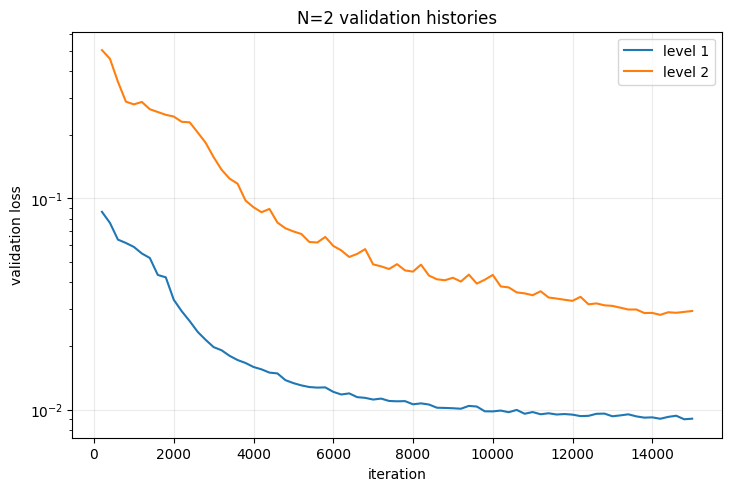

In [ ]:
models2 = {
    1: singleton_model,
    2: n2_model,
}

n2_training_summary = training_summary(
    2,
    {
        1: singleton_training,
        2: n2_training,
    },
)
n2_monitoring = monitoring_diagnostics(
    2,
    models2,
    CFG.diagnostic_size,
)
n2_network = network_diagnostics(
    2,
    models2,
    CFG.diagnostic_size,
)
n2_constraints = constraint_diagnostics(
    2,
    models2,
    CFG.diagnostic_size,
)
n2_z_gradient = z_gradient_consistency_diagnostics(
    2,
    models2,
    CFG.diagnostic_size,
)

show_table(n2_training_summary, "N=2 training summary")
show_table(n2_monitoring, "N=2 monitored first-exit diagnostics")
show_table(n2_network, "N=2 sampled range and symmetry diagnostics")
show_table(n2_constraints, "N=2 held-out boundary and terminal diagnostics")
show_table(n2_z_gradient, "N=2 Z versus sigma-gradient consistency")






plot_training_history(
    2,
    {
        1: singleton_training,
        2: n2_training,
    },
)

### Train and evaluate N=3


N3_level1                iter= 1000 val=6.3299e-02 stopped=3.879e-02 alive=2.789e-03 exit=4.515e-02 boundary=8.549e-03 terminal=1.117e-02 noninc=0.000e+00
N3_level1                iter= 2000 val=3.4273e-02 stopped=1.870e-02 alive=1.356e-03 exit=3.230e-02 boundary=5.210e-03 terminal=6.994e-03 noninc=0.000e+00
N3_level1                iter= 3000 val=1.9283e-02 stopped=1.311e-02 alive=8.443e-04 exit=2.861e-02 boundary=2.487e-03 terminal=7.371e-04 noninc=0.000e+00
N3_level1                iter= 4000 val=1.5192e-02 stopped=1.095e-02 alive=6.092e-04 exit=2.488e-02 boundary=1.250e-03 terminal=4.475e-04 noninc=0.000e+00
N3_level1                iter= 5000 val=1.3393e-02 stopped=9.971e-03 alive=5.087e-04 exit=2.291e-02 boundary=9.837e-04 terminal=9.635e-05 noninc=0.000e+00
N3_level1                iter= 6000 val=1.1612e-02 stopped=8.926e-03 alive=4.115e-04 exit=1.945e-02 boundary=4.358e-04 terminal=2.635e-04 noninc=0.000e+00
N3_level1                iter= 7000 val=1.0823e-02 stopped=8.209e-03 a

#### N=3 analytical singleton diagnostics

Time,MAE,RMSE,Maximum error,Singleton Z MAE,Singleton Z RMSE
0.000000,0.044094,0.049134,0.084838,0.052889,0.059404
0.500000,0.031364,0.040485,0.079480,0.058998,0.071998
0.900000,0.015308,0.028914,0.092628,0.102292,0.185621
0.950000,0.004362,0.009025,0.026824,0.148965,0.304879


#### N=3 training summary

N,Level,Best iteration,Best validation,Stopped,Living,Exit,Boundary,Terminal,Non-increasing,Range
3.000000,1.000000,15000.000000,0.009151,0.007678,0.000227,0.013488,0.000072,0.000030,0.000000,—
3.000000,2.000000,15000.000000,0.024099,0.015427,0.001548,0.031872,0.004693,0.000630,—,0.000153
3.000000,3.000000,15000.000000,0.050489,0.036924,0.002161,0.060530,0.006013,0.001268,—,0.000296


...

N,Level,Domain fraction,Field minimum,Field maximum,Range violation,Value symmetry error,Z equivariance error
3.000000,1.000000,1.000000,2.000000,2.994546,0.000000,0.000000,0.000000
3.000000,2.000000,0.437256,0.894928,2.768149,0.175321,0.000000,0.000000
3.000000,3.000000,0.601074,-0.121681,2.357256,0.121040,0.000000,0.000000


#### N=3 held-out boundary and terminal diagnostics

N,Level,Boundary MAE,Boundary RMSE,Terminal MAE,Terminal RMSE
3.000000,1.000000,0.007760,0.008469,0.002209,0.005648
3.000000,2.000000,0.038577,0.071966,0.017576,0.025152
3.000000,3.000000,0.052356,0.082548,0.025869,0.035085


#### N=3 Z versus sigma-gradient consistency

N,Level,Z-gradient MAE,Z-gradient RMSE
3.000000,1.000000,0.071733,0.249247
3.000000,2.000000,0.149618,0.258186
3.000000,3.000000,0.123547,0.214317


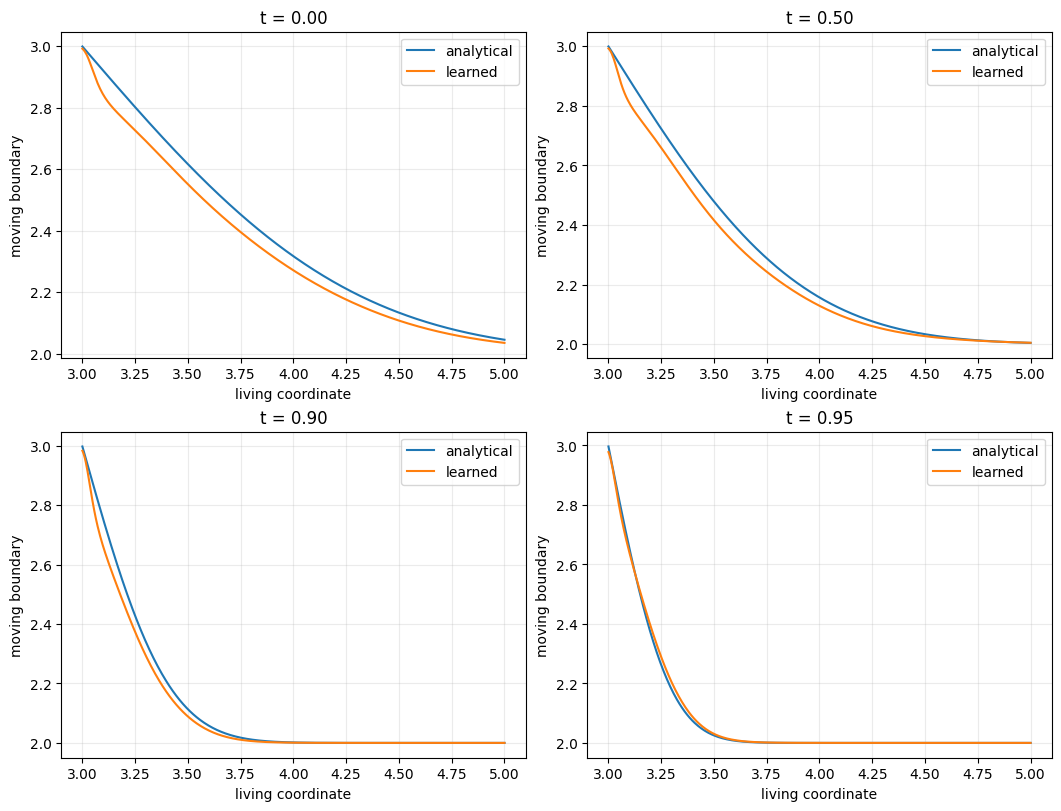

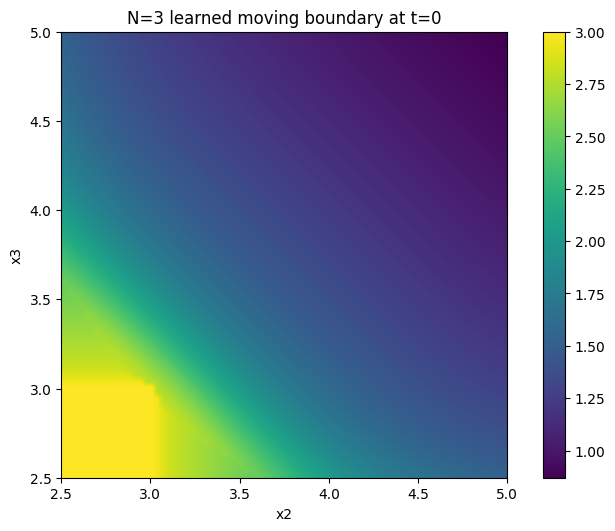

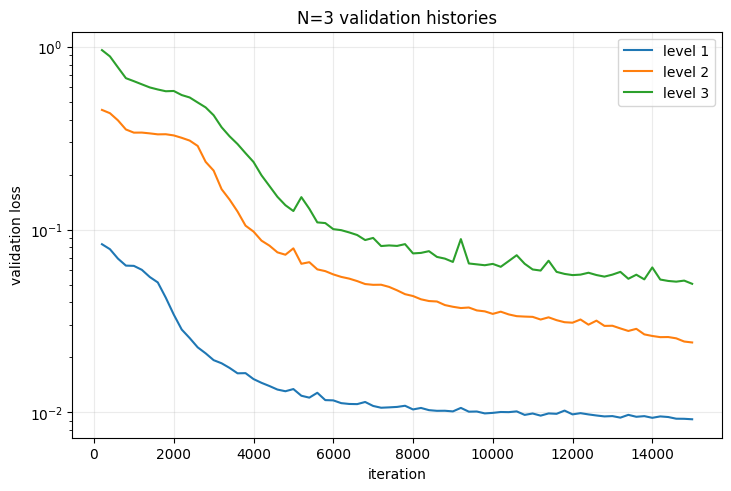

In [ ]:
models3, training3 = train_general_cascade(
    3,
    SEED + 3_000,
)

n3_singleton_metrics = (
    general_singleton_metrics(
        3,
        models3,
    )
)

n3_training_summary = training_summary(
    3,
    training3,
)
n3_monitoring = monitoring_diagnostics(
    3,
    models3,
    CFG.diagnostic_size,
)
n3_network = network_diagnostics(
    3,
    models3,
    CFG.diagnostic_size,
)
n3_constraints = constraint_diagnostics(
    3,
    models3,
    CFG.diagnostic_size,
)
n3_z_gradient = z_gradient_consistency_diagnostics(
    3,
    models3,
    CFG.diagnostic_size,
)

show_table(n3_singleton_metrics, "N=3 analytical singleton diagnostics")
show_table(n3_training_summary, "N=3 training summary")
show_table(n3_monitoring, "N=3 monitored first-exit diagnostics")
show_table(n3_network, "N=3 sampled domain, range and symmetry diagnostics")
show_table(n3_constraints, "N=3 held-out boundary and terminal diagnostics")
show_table(n3_z_gradient, "N=3 Z versus sigma-gradient consistency")

plot_general_singleton_boundary(
    3,
    models3,
)
plot_n3_boundary(
    models3
)
plot_training_history(
    3,
    training3,
)






### N=3 to N=2 consistency check


#### Post-training N=3 to N=2 dimensional-reduction consistency check

Far coordinate L,Exact-system direct-hit bound,Field MAE,Field RMSE,Boundary MAE,Boundary RMSE
4.000000,0.317311,0.380872,0.434385,0.315067,0.320762
4.500000,0.133614,0.182839,0.199740,0.129710,0.130326
5.000000,0.045500,0.086547,0.091454,0.019928,0.022542


#### L=5 dimensional-reduction consistency diagnostic

Far coordinate L,Exact-system direct-hit bound,Field MAE,Field RMSE,Boundary MAE,Boundary RMSE
5.000000,0.045500,0.086547,0.091454,0.019928,0.022542


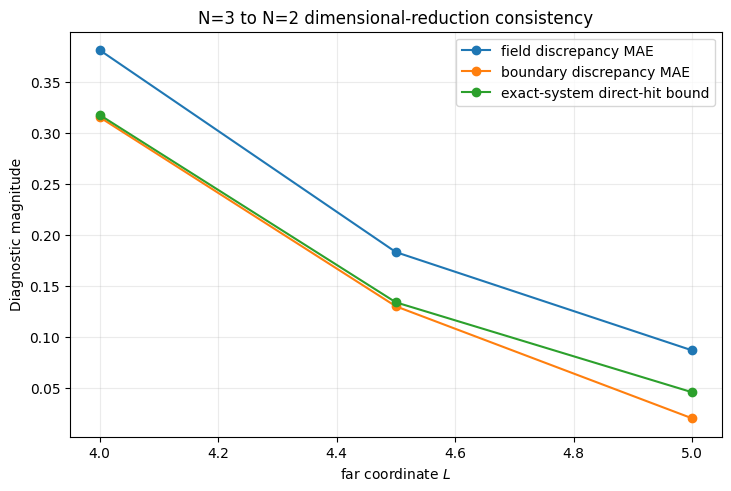

In [ ]:
n3_to_n2_check = projection_sweep(
    higher_total=3,
    higher_models=models3,
    lower_total=2,
    lower_models=models2,
    far_values=(4.0, 4.5, 5.0),
    samples=CFG.projection_samples,
)


show_table(n3_to_n2_check, "Post-training N=3 to N=2 dimensional-reduction consistency check")

n3_principal_check = (
    n3_to_n2_check[
        n3_to_n2_check[
            "far_coordinate"
        ] == 5.0
    ]
)

show_table(n3_principal_check, "L=5 dimensional-reduction consistency diagnostic")

plot_projection_sweep(
    n3_to_n2_check,
    3,
    2,
)

## 5. Results summary


In [ ]:
headline_results = pd.DataFrame(
    [
        {
            "Quantity": "N=2 singleton MAE at t=0",
            "Value": float(
                singleton_metrics.loc[
                    singleton_metrics["time"] == 0.0,
                    "singleton_MAE",
                ].iloc[0]
            ),
        },
        {
            "Quantity": "N=2 moving-boundary MAE at t=0",
            "Value": float(
                singleton_metrics.loc[
                    singleton_metrics["time"] == 0.0,
                    "boundary_MAE",
                ].iloc[0]
            ),
        },
        {
            "Quantity": "N=2 completed-field discrepancy MAE vs 40-step reference",
            "Value": float(n2_reference_metrics_40["field_MAE"]),
        },
        {
            "Quantity": "N=2 completed-field discrepancy MAE vs 400-step reference",
            "Value": float(n2_reference_metrics_400["field_MAE"]),
        },
        {
            "Quantity": "N=2 completed-field discrepancy RMSE vs 400-step reference",
            "Value": float(n2_reference_metrics_400["field_RMSE"]),
        },
        {
            "Quantity": "N=2 exact-geometry 40-vs-400 reference MAE",
            "Value": float(
                n2_reference_monitoring_sensitivity[
                    "reference_40_vs_400_MAE"
                ]
            ),
        },
        {
            "Quantity": "N=2 400-step reference mean Monte Carlo SE",
            "Value": float(
                n2_reference_metrics_400[
                    "reference_mean_MC_SE"
                ]
            ),
        },
        {
            "Quantity": "N=3 singleton MAE at t=0",
            "Value": float(
                n3_singleton_metrics.loc[
                    n3_singleton_metrics["time"] == 0.0,
                    "MAE",
                ].iloc[0]
            ),
        },
        {
            "Quantity": "N=3 to N=2 field discrepancy MAE at L=5",
            "Value": float(
                n3_principal_check["field_MAE"].iloc[0]
            ),
        },
        {
            "Quantity": "N=3 to N=2 boundary discrepancy MAE at L=5",
            "Value": float(
                n3_principal_check["boundary_MAE"].iloc[0]
            ),
        },
        {
            "Quantity": "N=3 exact-system direct-hit bound at L=5",
            "Value": float(
                n3_principal_check["max_boundary_hit_bound"].iloc[0]
            ),
        },
    ]
)


display(Markdown("### Dissertation headline diagnostics"))
display(
    headline_results.style
    .format({"Value": "{:.6f}"})
    .hide(axis="index")
)



### Dissertation headline diagnostics

Quantity,Value
N=2 singleton MAE at t=0,0.043391
N=2 moving-boundary MAE at t=0,0.043391
N=2 completed-field discrepancy MAE vs 40-step reference,0.037605
N=2 completed-field discrepancy MAE vs 400-step reference,0.073054
N=2 completed-field discrepancy RMSE vs 400-step reference,0.081816
N=2 exact-geometry 40-vs-400 reference MAE,0.040637
N=2 400-step reference mean Monte Carlo SE,0.009531
N=3 singleton MAE at t=0,0.044094
N=3 to N=2 field discrepancy MAE at L=5,0.086547
N=3 to N=2 boundary discrepancy MAE at L=5,0.019928
